# Zero-Shot Learning for Human Activity Recognition
## Using Sentence-BERT Semantic Prototypes on the PAMAP2 Dataset

---

### Abstract

Zero-Shot Learning (ZSL) enables a classifier to recognise activity classes it has never seen during training by bridging the gap between sensor signals and semantic descriptions. This notebook presents a rigorous ZSL pipeline on the **PAMAP2** inertial measurement unit (IMU) dataset. A Temporal Convolutional Network (TCN) maps raw sensor windows into a shared semantic embedding space, and class prototypes are generated by encoding rich, motion-aware activity descriptions with a strong **Sentence-BERT** model (`all-mpnet-base-v2`, 768-dim). We study two approaches:

| Approach | Strategy | Addresses |
|---|---|---|
| **Approach 1** | Nearest-prototype cosine matching | Baseline ZSL |
| **Approach 2** | Hubness-corrected matching (Inverted Softmax + Cross-modal Centering) | Hubness problem |

The hubness problem — a well-known pathology in high-dimensional nearest-neighbour search where a few prototypes become hubs (queried far too often) — is diagnosed explicitly and addressed in Approach 2.

---

### Table of Contents
1. Environment Setup  
2. Activity Definitions & Semantic Descriptions  
3. Data Loading (PAMAP2)  
4. Preprocessing  
5. Sliding-Window Segmentation  
6. Parameterised Seen / Unseen Split  
7. Feature Standardisation  
8. Sentence-BERT Semantic Prototypes  
9. TCN Encoder Architecture  
10. Training  
11. **Approach 1** — Nearest-Prototype ZSL & Hubness Diagnosis  
12. **Approach 2** — Hubness-Corrected ZSL  
13. Summary & Discussion  

---
## 1. Environment Setup

In [1]:
import os, glob, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.manifold import TSNE
from collections import Counter

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
CMAP = "Blues"

# ─── Reproducibility ────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ─── Hardware ────────────────────────────────────────────────────────────────
DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"
NUM_WORKERS = 0
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# ─── Visualisations output directory ───────────────────────────────────────
VIS_DIR = "visualisations"
os.makedirs(VIS_DIR, exist_ok=True)
print(f"Visualisations will be saved to: {os.path.abspath(VIS_DIR)}")

print(f"Device  : {DEVICE}")
print(f"PyTorch : {torch.__version__}")

Visualisations will be saved to: /Users/anikghosh/Desktop/test/Zero Shot Learning/visualisations
Device  : cpu
PyTorch : 2.11.0


---
## 2. Activity Definitions & Semantic Descriptions

Each activity is described by a rich, motion-aware sentence that captures the **biomechanical signature** visible in IMU data — frequency content, dominant axes, energy level, and postural context. These descriptions are later encoded by Sentence-BERT to form class prototypes. No hand-crafted feature vectors are used.

In [2]:
# ─── Numeric ID → short name ─────────────────────────────────────────────────
ACTIVITY_MAP = {
    1:  "lying",
    2:  "sitting",
    3:  "standing",
    4:  "walking",
    5:  "running",
    6:  "cycling",
    7:  "Nordic walking",
    9:  "watching TV",
    10: "computer work",
    11: "car driving",
    12: "ascending stairs",
    13: "descending stairs",
    16: "vacuum cleaning",
    17: "ironing",
    18: "folding laundry",
    19: "house cleaning",
    20: "playing soccer",
    24: "rope jumping",
}


---
## 3. Data Loading

The PAMAP2 dataset contains IMU recordings from 9 subjects performing up to 18 activities. Each `.dat` file stores a 54-column space-separated time-series at 100 Hz. We concatenate all Protocol and Optional session files into a single DataFrame.

In [3]:
DATA_ROOT = "PAMAP2_Dataset"  # ← change to your local path

def make_colnames():
    """Build the 54 canonical column names matching PAMAP2 format."""
    cols = ["timestamp", "label", "hr"]
    imu_parts = [
        "temp",
        "acc16_x", "acc16_y", "acc16_z",
        "acc6_x",  "acc6_y",  "acc6_z",
        "gyro_x",  "gyro_y",  "gyro_z",
        "mag_x",   "mag_y",   "mag_z",
        "ori_1",   "ori_2",   "ori_3",   "ori_4",
    ]
    for loc in ["hand", "chest", "ankle"]:
        cols += [f"{loc}_{p}" for p in imu_parts]
    assert len(cols) == 54, f"Expected 54 columns, got {len(cols)}"
    return cols

COLS = make_colnames()

def load_all_sessions(data_root=DATA_ROOT):
    """Load all subject .dat files from Protocol and Optional folders."""
    dfs = []
    for part in ["Protocol", "Optional"]:
        folder = os.path.join(data_root, part)
        for f in sorted(glob.glob(os.path.join(folder, "subject*.dat"))):
            df = pd.read_csv(f, sep=r"\s+", header=None, names=COLS, engine="python")
            df["session"] = part.lower()
            df["subject"] = os.path.splitext(os.path.basename(f))[0]
            dfs.append(df)
    if not dfs:
        raise FileNotFoundError(
            f"No subject*.dat files found under '{data_root}/Protocol' "
            f"or '{data_root}/Optional'. Please set DATA_ROOT correctly."
        )
    return pd.concat(dfs, ignore_index=True)

raw = load_all_sessions()
print(f"Raw data shape : {raw.shape}")
print(f"Subjects       : {sorted(raw['subject'].unique())}")
print(f"Activity IDs   : {sorted(raw['label'].dropna().astype(int).unique())}")

Raw data shape : (3850505, 56)
Subjects       : ['subject101', 'subject102', 'subject103', 'subject104', 'subject105', 'subject106', 'subject107', 'subject108', 'subject109']
Activity IDs   : [0, 1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 13, 16, 17, 18, 19, 20, 24]


---
## 4. Preprocessing

We apply the following cleaning steps:

- **Remove label 0** (transition / unlabelled rows).
- **Drop orientation quaternions** (unreliable in many sessions).
- **Drop the ±6g accelerometer** channels (saturate during high-intensity activities; ±16g is preferred).
- **Temporal interpolation** within each subject–session group to fill isolated NaN gaps (sensor dropouts).
- **Row-level NaN filter**: discard rows where more than 30 % of features remain NaN after interpolation.

In [4]:
ORI_COLS  = [c for c in COLS if "_ori_" in c]
ACC6_COLS = [c for c in COLS if "_acc6_" in c]

def preprocess_pamap2(
    df: pd.DataFrame,
    drop_orientation: bool = True,
    drop_acc6: bool = True,
    keep_hr: bool = True,
    max_nan_frac_per_row: float = 0.30
) -> pd.DataFrame:
    df = df.copy()

    # --- Label cleaning ---
    df["label"] = pd.to_numeric(df["label"], errors="coerce")
    df = df[df["label"].notna()]
    df["label"] = df["label"].astype(int)
    df = df[df["label"] != 0].reset_index(drop=True)

    # --- Channel selection ---
    if drop_orientation:
        df = df.drop(columns=ORI_COLS, errors="ignore")
    if drop_acc6:
        df = df.drop(columns=ACC6_COLS, errors="ignore")
    if not keep_hr:
        df = df.drop(columns=["hr"], errors="ignore")

    for c in df.columns:
        if c not in ["subject", "session"]:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    feat_cols = [c for c in df.columns if c not in ["subject", "session", "label"]]

    # --- Per-session interpolation ---
    def impute_group(g):
        g = g.sort_values("timestamp")
        g[feat_cols] = g[feat_cols].interpolate(limit_direction="both")
        g[feat_cols] = g[feat_cols].ffill().bfill()
        return g

    df = df.groupby(["subject", "session"], group_keys=False).apply(impute_group)

    # --- Row-level NaN filter ---
    nan_frac = df[feat_cols].isna().mean(axis=1)
    df = df[nan_frac <= max_nan_frac_per_row].reset_index(drop=True)
    df = df.dropna().reset_index(drop=True)

    return df

df = preprocess_pamap2(raw)
print(f"Preprocessed shape : {df.shape}")
print(f"Feature columns    : {len([c for c in df.columns if c not in ['subject','session','label','timestamp']])}")

Preprocessed shape : (2724953, 35)
Feature columns    : 31


---
## 5. Sliding-Window Segmentation

IMU time-series are segmented into fixed-length windows with 50 % overlap. A **purity filter** discards windows where the majority-class vote is below a threshold, ensuring each window cleanly represents one activity.

In [5]:
FEATURE_COLS = [c for c in df.columns if c not in ["subject", "session", "label", "timestamp"]]

WINDOW_SIZE_TRAIN = 500    # 5 s at 100 Hz  (training & validation)
WINDOW_SIZE_TEST  = 1000   # 10 s at 100 Hz (test — more context)
STRIDE_TRAIN      = 250    # 50 % overlap
STRIDE_TEST       = 500
PURITY_THRESH     = 0.85   # ≥ 85 % of frames must share the majority label

def make_windows(df: pd.DataFrame, feature_cols, window_size, stride, purity_thresh):
    X, y, pur, meta = [], [], [], []
    for (subject, session), g in df.groupby(["subject", "session"]):
        g      = g.sort_values("timestamp")
        values = g[feature_cols].to_numpy(dtype=np.float32)
        labels = g["label"].to_numpy(dtype=np.int64)
        n      = len(g)
        for start in range(0, n - window_size + 1, stride):
            end   = start + window_size
            wlab  = labels[start:end]
            binc  = np.bincount(wlab)
            maj   = int(binc.argmax())
            purity = float(binc.max()) / window_size
            if purity < purity_thresh:
                continue
            X.append(values[start:end])
            y.append(maj)
            pur.append(purity)
            meta.append((subject, session))

    X    = np.stack(X) if X else np.empty((0, window_size, len(feature_cols)), dtype=np.float32)
    y    = np.array(y,   dtype=np.int64)
    pur  = np.array(pur, dtype=np.float32)
    meta = pd.DataFrame(meta, columns=["subject", "session"])
    return X, y, pur, meta

X_trw, y_trw, pur_tr, meta_tr = make_windows(df, FEATURE_COLS, WINDOW_SIZE_TRAIN, STRIDE_TRAIN, PURITY_THRESH)
X_tew, y_tew, pur_te, meta_te = make_windows(df, FEATURE_COLS, WINDOW_SIZE_TEST,  STRIDE_TEST,  PURITY_THRESH)

print(f"Train/Val windows ({WINDOW_SIZE_TRAIN} frames): {X_trw.shape}  |  avg purity: {pur_tr.mean():.3f}")
print(f"Test windows      ({WINDOW_SIZE_TEST} frames): {X_tew.shape}  |  avg purity: {pur_te.mean():.3f}")

Train/Val windows (500 frames): (10733, 500, 31)  |  avg purity: 0.999
Test windows      (1000 frames): (5265, 1000, 31)  |  avg purity: 0.999


---
## 6. Parameterised Seen / Unseen Split

The ZSL evaluation protocol splits activity classes into **seen** (training) and **unseen** (test-only) subsets. The unseen classes must **never** appear during model training. We further hold out the last two subjects as test subjects.

### Key parameters
| Parameter | Default | Description |
|---|---|---|
| `N_UNSEEN` | 4 | Number of unseen (zero-shot) classes |
| `UNSEEN_IDS` | `[5, 13, 16, 18]` | Specific class IDs to hold out (override auto-selection) |
| `N_TEST_SUBJECTS` | 2 | Subjects reserved for test (unseen evaluation) |

> **To change the split**: edit `UNSEEN_IDS` (or set `UNSEEN_IDS = None` and `N_UNSEEN` to auto-select the last N classes).

In [6]:
# ─── Parameterisation ────────────────────────────────────────────────────────

UNSEEN_IDS      = [5, 13, 16, 18]   # set to None for automatic selection
N_UNSEEN        = len(UNSEEN_IDS)           # how many classes to treat as zero-shot
N_TEST_SUBJECTS = 2           # subjects reserved purely for ZSL evaluation
VAL_FRAC        = 0.15        # fraction of seen-class windows for validation

print(f'Ratio of seen : unseen : {(18 - len(UNSEEN_IDS))/len(UNSEEN_IDS)}')

# ─── Resolve class lists ─────────────────────────────────────────────────────
ALL_LABELS = sorted(set(y_trw.tolist() + y_tew.tolist()))

if UNSEEN_IDS is not None:
    UNSEEN = [l for l in UNSEEN_IDS if l in ALL_LABELS]
else:
    UNSEEN = ALL_LABELS[-N_UNSEEN:]   # auto: last N by ID

SEEN = [l for l in ALL_LABELS if l not in UNSEEN]

assert len(UNSEEN) >= 2, "Need at least 2 unseen classes for a meaningful evaluation."
assert len(SEEN)   >= 2, "Need at least 2 seen classes to train."

# ─── Subject split ───────────────────────────────────────────────────────────
subjects      = sorted(meta_tr["subject"].unique())
n_hold        = min(N_TEST_SUBJECTS, len(subjects) - 1)
test_subjects = subjects[-n_hold:]

is_test_subj_tr = meta_tr["subject"].isin(test_subjects).values
is_test_subj_te = meta_te["subject"].isin(test_subjects).values

# ─── Build splits ────────────────────────────────────────────────────────────
X_train_all, y_train_all = X_trw[~is_test_subj_tr], y_trw[~is_test_subj_tr]
seen_mask                = np.isin(y_train_all, SEEN)
X_seen, y_seen           = X_train_all[seen_mask], y_train_all[seen_mask]

perm  = np.random.permutation(len(X_seen))
n_val = int(len(perm) * VAL_FRAC)
val_idx, tr_idx = perm[:n_val], perm[n_val:]

X_tr,  y_tr  = X_seen[tr_idx],  y_seen[tr_idx]
X_val, y_val = X_seen[val_idx], y_seen[val_idx]

X_test_all, y_test_all = X_tew[is_test_subj_te], y_tew[is_test_subj_te]
unseen_mask             = np.isin(y_test_all, UNSEEN)
X_test_u, y_test_u     = X_test_all[unseen_mask], y_test_all[unseen_mask]

# ─── Summary ─────────────────────────────────────────────────────────────────
print("=" * 60)
print(f"  N_UNSEEN        : {N_UNSEEN}")
print(f"  N_TEST_SUBJECTS : {N_TEST_SUBJECTS}")
print()
print(f"  Test subjects   : {test_subjects}")
print(f"  SEEN classes    : {[ACTIVITY_MAP.get(i, i) for i in SEEN]}")
print(f"  UNSEEN classes  : {[ACTIVITY_MAP.get(i, i) for i in UNSEEN]}")
print()
print(f"  Train windows   : {X_tr.shape[0]}")
print(f"  Val   windows   : {X_val.shape[0]}")
print(f"  Test  windows   : {X_test_u.shape[0]}  (unseen classes only)")
print("=" * 60)

Ratio of seen : unseen : 3.5
  N_UNSEEN        : 4
  N_TEST_SUBJECTS : 2

  Test subjects   : ['subject108', 'subject109']
  SEEN classes    : ['lying', 'sitting', 'standing', 'walking', 'cycling', 'Nordic walking', 'watching TV', 'computer work', 'car driving', 'ascending stairs', 'ironing', 'house cleaning', 'playing soccer', 'rope jumping']
  UNSEEN classes  : ['running', 'descending stairs', 'vacuum cleaning', 'folding laundry']

  Train windows   : 5930
  Val   windows   : 1046
  Test  windows   : 194  (unseen classes only)


---
## 7. Feature Standardisation

All features are z-scored using **training-set statistics only**, avoiding any data leakage from validation or test splits.

In [7]:
eps = 1e-6
mu  = X_tr.reshape(-1, X_tr.shape[-1]).mean(axis=0)
sd  = X_tr.reshape(-1, X_tr.shape[-1]).std(axis=0) + eps

X_tr_n     = (X_tr     - mu) / sd
X_val_n    = (X_val    - mu) / sd
X_test_u_n = (X_test_u - mu) / sd

print(f"Normalised train  : {X_tr_n.shape}")
print(f"Normalised val    : {X_val_n.shape}")
print(f"Normalised test   : {X_test_u_n.shape}")

Normalised train  : (5930, 500, 31)
Normalised val    : (1046, 500, 31)
Normalised test   : (194, 1000, 31)


---
## 8. Sentence-BERT Semantic Prototypes

We use `all-mpnet-base-v2` — one of the strongest general-purpose Sentence-BERT models — to encode the motion-aware class descriptions into 768-dimensional unit vectors. These vectors serve as **class prototypes** in the shared embedding space. The choice of a powerful sentence encoder is critical: richer, more discriminative prototypes directly improve zero-shot matching.

> **Note:** No hand-crafted attribute vectors (e.g. `LABEL_TEXT` dictionaries) are used — the model reads natural language descriptions and projects them into the semantic space autonomously.

In [8]:
from sentence_transformers import SentenceTransformer

print("Loading Sentence-BERT model: all-mpnet-base-v2 …")
sbert = SentenceTransformer("all-mpnet-base-v2")

class_ids = sorted(ALL_LABELS)
# Use the short activity label name directly as the text for SBERT encoding
texts     = [ACTIVITY_MAP.get(cid, str(cid)) for cid in class_ids]

# Encode all class label names → L2-normalised prototype matrix  [C × D]
S       = sbert.encode(texts, normalize_embeddings=True).astype(np.float32)
SEM_DIM = S.shape[1]
row_idx = {cid: i for i, cid in enumerate(class_ids)}

print(f"\nPrototype matrix S : {S.shape}  (C={len(class_ids)} classes × D={SEM_DIM} dims)")
print(f"\nSample encodings:")
for cid in UNSEEN:
    print(f"  [{cid}] {ACTIVITY_MAP.get(cid, cid):<22}  |  norm={np.linalg.norm(S[row_idx[cid]]):.4f}")

Loading Sentence-BERT model: all-mpnet-base-v2 …

Prototype matrix S : (18, 768)  (C=18 classes × D=768 dims)

Sample encodings:
  [5] running                 |  norm=1.0000
  [13] descending stairs       |  norm=1.0000
  [16] vacuum cleaning         |  norm=1.0000
  [18] folding laundry         |  norm=1.0000


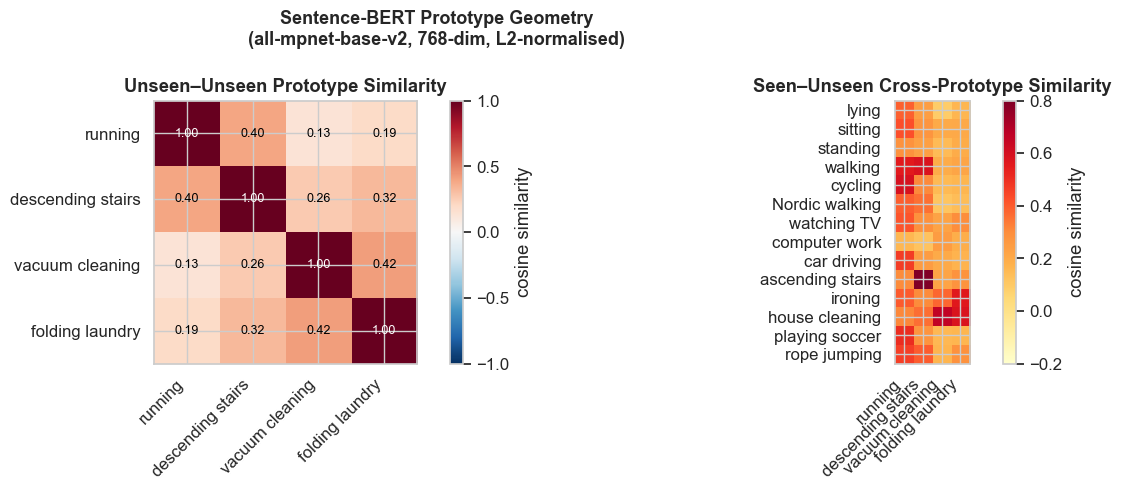


Observation: ideally the off-diagonal cells in the left heatmap are close to 0 (discriminative prototypes).


In [9]:
# ─── Visualisation: Prototype Cosine Similarity Heatmaps ─────────────────────

unseen_idx = [row_idx[c] for c in UNSEEN]
seen_idx   = [row_idx[c] for c in SEEN]

S_un    = S[unseen_idx]           # [n_unseen × D]
S_se    = S[seen_idx]             # [n_seen   × D]
sim_uu  = S_un @ S_un.T           # unseen–unseen
sim_su  = S_se @ S_un.T           # seen–unseen (cross)

names_un = [ACTIVITY_MAP.get(i, str(i)) for i in UNSEEN]
names_se = [ACTIVITY_MAP.get(i, str(i)) for i in SEEN]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Unseen–Unseen ---
im0 = axes[0].imshow(sim_uu, vmin=-1, vmax=1, cmap="RdBu_r")
axes[0].set_title("Unseen–Unseen Prototype Similarity", fontweight="bold")
axes[0].set_xticks(range(len(names_un))); axes[0].set_xticklabels(names_un, rotation=45, ha="right")
axes[0].set_yticks(range(len(names_un))); axes[0].set_yticklabels(names_un)
for i in range(len(names_un)):
    for j in range(len(names_un)):
        axes[0].text(j, i, f"{sim_uu[i,j]:.2f}", ha="center", va="center", fontsize=9,
                     color="white" if abs(sim_uu[i,j]) > 0.5 else "black")
plt.colorbar(im0, ax=axes[0], label="cosine similarity")

# --- Seen–Unseen (cross) ---
im1 = axes[1].imshow(sim_su, vmin=-0.2, vmax=0.8, cmap="YlOrRd")
axes[1].set_title("Seen–Unseen Cross-Prototype Similarity", fontweight="bold")
axes[1].set_xticks(range(len(names_un))); axes[1].set_xticklabels(names_un, rotation=45, ha="right")
axes[1].set_yticks(range(len(names_se))); axes[1].set_yticklabels(names_se)
plt.colorbar(im1, ax=axes[1], label="cosine similarity")

fig.suptitle("Sentence-BERT Prototype Geometry\n"
             "(all-mpnet-base-v2, 768-dim, L2-normalised)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, "prototype_similarity_heatmaps.png"), dpi=150, bbox_inches="tight")
plt.show()
plt.close()

print("\nObservation: ideally the off-diagonal cells in the left heatmap are"
      " close to 0 (discriminative prototypes).")

---
## 9. TCN Encoder Architecture

A **Temporal Convolutional Network (TCN)** maps each sensor window `[T × F]` to a 768-dimensional unit vector that can be compared against Sentence-BERT class prototypes. Key design choices:

- **Dilated causal convolutions** with exponentially growing dilation rates capture multi-scale temporal context.
- **Residual connections** per block stabilise gradient flow in deep stacks.
- **Global average pooling** collapses the time dimension before the projection head.
- **L2 normalisation** at the output aligns the embedding onto the same unit hypersphere as the SBERT prototypes.

In [10]:
class TCNBlock(nn.Module):
    """Dilated residual TCN block: two dilated conv layers with BN + ReLU + dropout."""
    def __init__(self, in_ch, out_ch, k=5, d=1, dropout=0.2):
        super().__init__()
        pad = (k - 1) * d // 2
        self.net = nn.Sequential(
            nn.Conv1d(in_ch,  out_ch, kernel_size=k, dilation=d, padding=pad),
            nn.BatchNorm1d(out_ch),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Conv1d(out_ch, out_ch, kernel_size=k, dilation=d, padding=pad),
            nn.BatchNorm1d(out_ch),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.res = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x):
        return self.net(x) + self.res(x)


class TCNEncoder(nn.Module):
    """Stack of dilated TCN blocks; returns a global average-pooled feature vector."""
    def __init__(self, n_features, channels=(64, 96, 128), k=5, dropout=0.2):
        super().__init__()
        blocks, in_ch, d = [], n_features, 1
        for out_ch in channels:
            blocks.append(TCNBlock(in_ch, out_ch, k=k, d=d, dropout=dropout))
            in_ch = out_ch
            d    *= 2
        self.tcn = nn.Sequential(*blocks)

    def forward(self, x):
        x = x.transpose(1, 2)   # [B, T, F] → [B, F, T]
        return self.tcn(x).mean(dim=2)   # global avg pool → [B, out_ch]


class ZSLModel(nn.Module):
    """
    Full ZSL model:
      TCNEncoder → projection head → L2-normalised embedding.

    Output lives on the unit hypersphere, enabling direct cosine
    comparison against Sentence-BERT class prototypes.
    """
    def __init__(self, n_features, emb_dim,
                 enc_channels=(64, 96, 128), proj=512, dropout=0.2):
        super().__init__()
        self.enc  = TCNEncoder(n_features, channels=enc_channels, k=5, dropout=dropout)
        self.head = nn.Sequential(
            nn.Linear(enc_channels[-1], proj),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(proj, emb_dim),
        )

    def forward(self, x):
        z = self.head(self.enc(x))
        return z / (z.norm(dim=1, keepdim=True) + 1e-8)   # unit sphere


model = ZSLModel(
    n_features=X_tr_n.shape[-1],
    emb_dim=SEM_DIM,
).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f"Model parameters : {n_params:.2f} M")
print(f"Output emb dim   : {SEM_DIM}  (matches Sentence-BERT)")

Model parameters : 0.73 M
Output emb dim   : 768  (matches Sentence-BERT)


---
## 10. Training

### Loss: Scaled Cross-Entropy on Semantic Logits

At each step, the TCN embedding for a seen-class window is compared against **all** class prototypes via cosine similarity, scaled by a temperature $\tau$:

$$\mathcal{L} = -\log \frac{\exp(\mathbf{e}_i^\top \mathbf{s}_{y_i} / \tau)}{\sum_{c} \exp(\mathbf{e}_i^\top \mathbf{s}_c / \tau)}$$

This forces the model to align sensor embeddings with the correct Sentence-BERT prototype, enabling zero-shot transfer to unseen classes at inference time.

### Training details
- **Optimiser**: AdamW with weight decay $10^{-4}$
- **Scheduler**: Cosine annealing (no warm-up)
- **Early stopping**: patience on validation *seen-class* accuracy

In [11]:
class WindowDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

BATCH_SIZE   = 256 if DEVICE == "cuda" else 128

train_loader = DataLoader(WindowDataset(X_tr_n,     y_tr),     batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=NUM_WORKERS, drop_last=True)
val_loader   = DataLoader(WindowDataset(X_val_n,    y_val),    batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(WindowDataset(X_test_u_n, y_test_u), batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS)

print(f"Train batches : {len(train_loader)}")
print(f"Val   batches : {len(val_loader)}")
print(f"Test  batches : {len(test_loader)}")

Train batches : 46
Val   batches : 9
Test  batches : 2


In [12]:
# ─── Helper utilities ────────────────────────────────────────────────────────

S_t = torch.tensor(S, dtype=torch.float32, device=DEVICE)   # prototypes on GPU

def semantic_logits(pred_emb, proto_emb, temperature=0.07):
    """Cosine-similarity logits scaled by temperature."""
    return (pred_emb @ proto_emb.T) / temperature


@torch.no_grad()
def eval_nearest(model, loader, candidate_ids):
    """Nearest-prototype accuracy over a DataLoader."""
    model.eval()
    cand_idx = torch.tensor([row_idx[c] for c in candidate_ids], device=DEVICE)
    proto    = S_t[cand_idx]
    yt, yp   = [], []
    for xb, yb in loader:
        e = model(xb.to(DEVICE))
        k = torch.argmax(e @ proto.T, dim=1).cpu().numpy()
        yt.append(yb.numpy())
        yp.append(np.array([candidate_ids[i] for i in k], dtype=np.int64))
    yt = np.concatenate(yt)
    yp = np.concatenate(yp)
    return float((yt == yp).mean()), yt, yp


@torch.no_grad()
def collect_embeddings(model, loader, max_points=None):
    """Collect all (embedding, label) pairs from a DataLoader."""
    model.eval()
    E, Y = [], []
    for xb, yb in loader:
        E.append(model(xb.to(DEVICE)).cpu().numpy())
        Y.append(yb.numpy())
        if max_points and sum(len(a) for a in E) >= max_points:
            break
    E = np.concatenate(E)
    Y = np.concatenate(Y)
    if max_points:
        E, Y = E[:max_points], Y[:max_points]
    return E, Y

print("Helper functions defined.")

Helper functions defined.


In [19]:
# ─── Training loop ───────────────────────────────────────────────────────────
EPOCHS    = 15
LR        = 2e-3
TEMP      = 0.07
PATIENCE  = 10
MIN_DELTA = 1e-4

optimiser = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=EPOCHS)

best_val_acc = 0.0
best_state   = None
bad_epochs   = 0
history      = {"train_loss": [], "val_seen_acc": []}

for ep in range(1, EPOCHS + 1):
    # ── Train ──
    model.train()
    running, n = 0.0, 0
    for xb, yb in train_loader:
        xb  = xb.to(DEVICE)
        tgt = torch.tensor(
            [row_idx[int(l)] for l in yb.numpy()], device=DEVICE, dtype=torch.long
        )
        e    = model(xb)
        loss = nn.functional.cross_entropy(semantic_logits(e, S_t, TEMP), tgt)
        optimiser.zero_grad(set_to_none=True)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimiser.step()
        running += float(loss.item()) * len(xb)
        n       += len(xb)

    train_loss = running / max(n, 1)

    # ── Validate ──
    val_acc, _, _ = eval_nearest(model, val_loader, SEEN)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_seen_acc"].append(val_acc)

    print(f"Epoch {ep:02d}/{EPOCHS}  |  loss={train_loss:.4f}  |  val_seen_acc={val_acc:.3f}")

    # ── Early stopping ──
    if val_acc > best_val_acc + MIN_DELTA:
        best_val_acc = val_acc
        best_state   = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        bad_epochs   = 0
    else:
        bad_epochs += 1
        if bad_epochs >= PATIENCE:
            print(f"\n⏹  Early stop at epoch {ep}. Best val seen accuracy: {best_val_acc:.3f}")
            break

if best_state:
    model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})
    print("\n✔  Best checkpoint restored.")

Epoch 01/15  |  loss=0.0691  |  val_seen_acc=0.986
Epoch 02/15  |  loss=0.0552  |  val_seen_acc=0.988
Epoch 03/15  |  loss=0.0342  |  val_seen_acc=0.983
Epoch 04/15  |  loss=0.0236  |  val_seen_acc=0.988
Epoch 05/15  |  loss=0.0324  |  val_seen_acc=0.986
Epoch 06/15  |  loss=0.0272  |  val_seen_acc=0.987
Epoch 07/15  |  loss=0.0144  |  val_seen_acc=0.991
Epoch 08/15  |  loss=0.0118  |  val_seen_acc=0.990


KeyboardInterrupt: 

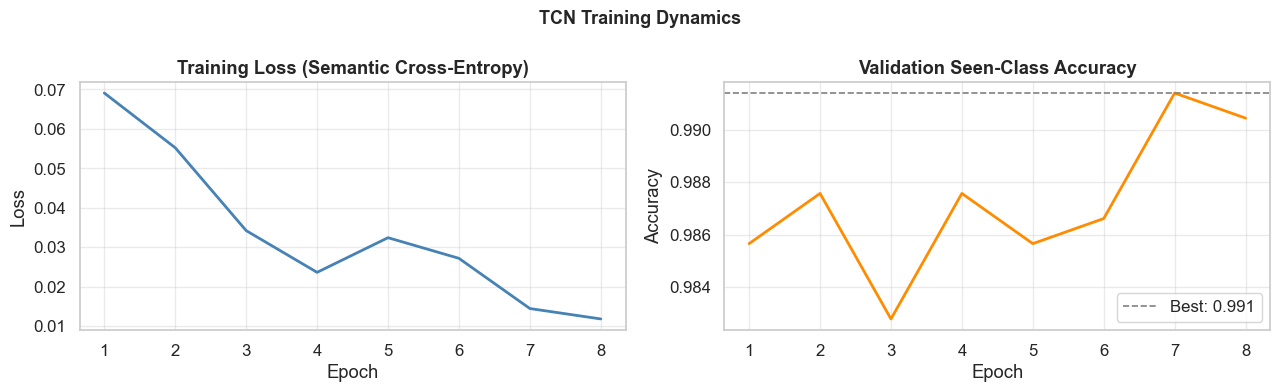

In [20]:
# ─── Learning curves ─────────────────────────────────────────────────────────
epochs_ran = len(history["train_loss"])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(range(1, epochs_ran + 1), history["train_loss"], color="steelblue", linewidth=2)
ax1.set_title("Training Loss (Semantic Cross-Entropy)", fontweight="bold")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax1.grid(True, alpha=0.4)

ax2.plot(range(1, epochs_ran + 1), history["val_seen_acc"], color="darkorange", linewidth=2)
ax2.axhline(best_val_acc, color="gray", linestyle="--", linewidth=1.2, label=f"Best: {best_val_acc:.3f}")
ax2.set_title("Validation Seen-Class Accuracy", fontweight="bold")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
ax2.legend(); ax2.grid(True, alpha=0.4)

plt.suptitle("TCN Training Dynamics", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, "training_curves.png"), dpi=150, bbox_inches="tight")
plt.show()
plt.close()

---
## 11. Approach 1 — Nearest-Prototype ZSL

### Method

At inference time each test-window embedding $\mathbf{e}$ is assigned to the unseen class whose prototype $\mathbf{s}_c$ maximises cosine similarity:

$$\hat{y} = \underset{c \in \mathcal{U}}{\arg\max}\; \mathbf{e}^\top \mathbf{s}_c$$

### Hubness problem

In high-dimensional spaces (here 768-dim), a well-known phenomenon called the **hubness problem** occurs: a few prototypes become *hubs* — they are returned as the nearest neighbour far more often than chance, even for queries that do not truly belong to them. This inflates recall for hub classes and suppresses it for anti-hub classes. We diagnose hubness via the **N-occurrence distribution** (how many times each prototype is the nearest neighbour) and the **skewness** of this distribution ($S_k > 0$ → hubness present).

In [21]:
# ─── Collect test embeddings ─────────────────────────────────────────────────
E_unseen, y_true = collect_embeddings(model, test_loader)
proto_unseen     = np.stack([S[row_idx[c]] for c in UNSEEN], axis=0)  # [n_unseen × D]

# ─── Approach 1: cosine nearest-prototype ────────────────────────────────────
sims_a1  = E_unseen @ proto_unseen.T          # [N × n_unseen]
pred_a1  = np.array(
    [UNSEEN[i] for i in sims_a1.argmax(axis=1)], dtype=np.int64
)
acc_a1 = float((pred_a1 == y_true).mean())

print("=" * 50)
print("APPROACH 1 — Nearest-Prototype ZSL")
print(f"  Top-1 Accuracy : {acc_a1:.4f}")
print("=" * 50)

target_names = [ACTIVITY_MAP.get(i, str(i)) for i in UNSEEN]
print()
print(classification_report(
    y_true, pred_a1, labels=UNSEEN, target_names=target_names, zero_division=0
))

APPROACH 1 — Nearest-Prototype ZSL
  Top-1 Accuracy : 0.5825

                   precision    recall  f1-score   support

          running       0.00      0.00      0.00        31
descending stairs       0.19      1.00      0.32        17
  vacuum cleaning       1.00      0.04      0.08        47
  folding laundry       0.97      0.95      0.96        99

         accuracy                           0.58       194
        macro avg       0.54      0.50      0.34       194
     weighted avg       0.75      0.58      0.54       194



In [22]:
# ─── Hubness Diagnosis ───────────────────────────────────────────────────────

# N-occurrence: how many times each prototype is the NN
nn_counts    = np.bincount(sims_a1.argmax(axis=1), minlength=len(UNSEEN))
nn_counts_pct = nn_counts / nn_counts.sum() * 100

# Similarity margin: top-1 – top-2 cosine similarity per query
top2    = np.sort(sims_a1, axis=1)[:, -2:]
margins = top2[:, 1] - top2[:, 0]

# Skewness of N-occurrence distribution
from scipy.stats import skew
skewness = float(skew(nn_counts))
is_hubby = skewness > 1.0

print("─" * 50)
print("Hubness Diagnosis")
print(f"  N-occurrence skewness  : {skewness:.3f}")
print(f"  Hubness detected       : {'⚠️  YES' if is_hubby else 'No significant hubness'}")
print()
print("  Prototype N-occurrence:")
for nm, cnt, pct in zip(target_names, nn_counts, nn_counts_pct):
    bar = "█" * int(pct / 2)
    print(f"    {nm:<24} {cnt:>5} ({pct:5.1f}%)  {bar}")
print()
print(f"  Margin: mean={margins.mean():.4f}  median={np.median(margins):.4f}  "
      f"10th-pct={np.percentile(margins,10):.4f}")
print("─" * 50)

──────────────────────────────────────────────────
Hubness Diagnosis
  N-occurrence skewness  : 0.009
  Hubness detected       : No significant hubness

  Prototype N-occurrence:
    running                      6 (  3.1%)  █
    descending stairs           89 ( 45.9%)  ██████████████████████
    vacuum cleaning              2 (  1.0%)  
    folding laundry             97 ( 50.0%)  █████████████████████████

  Margin: mean=0.1491  median=0.1251  10th-pct=0.0219
──────────────────────────────────────────────────


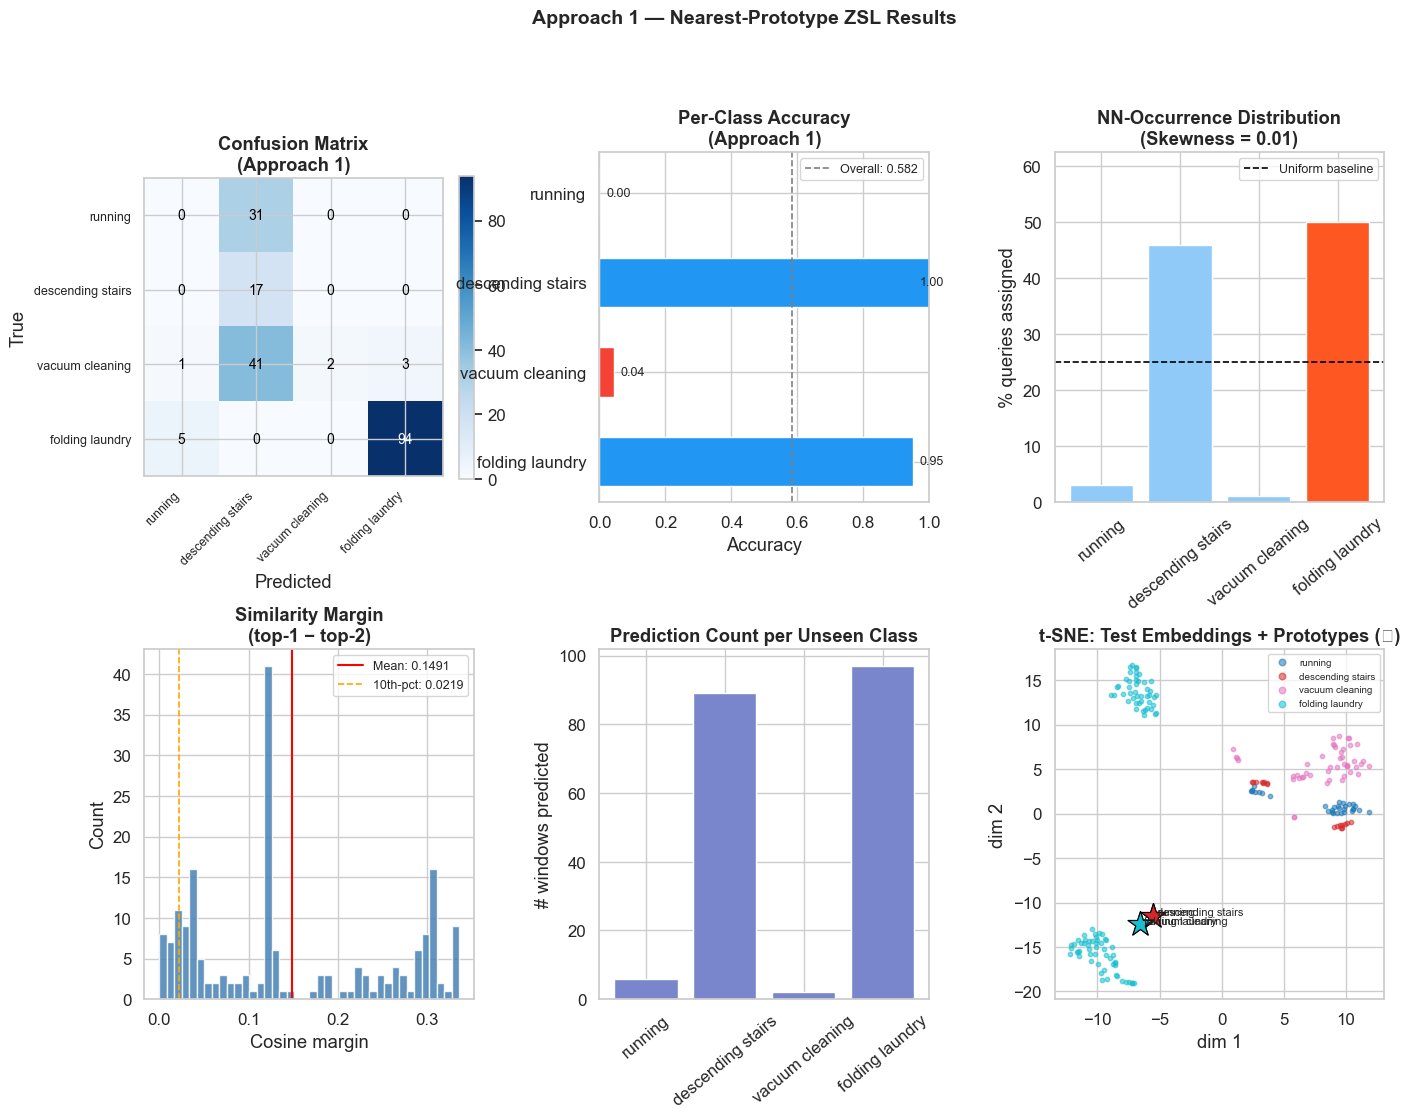


Approach 1 Overall ZSL Accuracy: 0.5825


In [23]:
# ─── Approach 1 Visualisations ───────────────────────────────────────────────

fig = plt.figure(figsize=(16, 11))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.38)

# 1a. Confusion matrix
ax0 = fig.add_subplot(gs[0, 0])
cm  = confusion_matrix(y_true, pred_a1, labels=UNSEEN)
im  = ax0.imshow(cm, cmap=CMAP)
ax0.set_title("Confusion Matrix\n(Approach 1)", fontweight="bold")
ax0.set_xticks(range(len(target_names))); ax0.set_xticklabels(target_names, rotation=45, ha="right", fontsize=9)
ax0.set_yticks(range(len(target_names))); ax0.set_yticklabels(target_names, fontsize=9)
ax0.set_xlabel("Predicted"); ax0.set_ylabel("True")
for i in range(len(target_names)):
    for j in range(len(target_names)):
        ax0.text(j, i, str(cm[i,j]), ha="center", va="center", fontsize=10,
                 color="white" if cm[i,j] > cm.max()*0.6 else "black")
plt.colorbar(im, ax=ax0, fraction=0.046)

# 1b. Per-class accuracy bar
ax1 = fig.add_subplot(gs[0, 1])
per_cls_acc = [float((pred_a1[y_true == c] == c).mean()) if (y_true == c).sum() > 0 else 0
               for c in UNSEEN]
colors = ["#2196F3" if a >= 0.5 else "#F44336" for a in per_cls_acc]
bars   = ax1.barh(target_names, per_cls_acc, color=colors, edgecolor="white", height=0.55)
ax1.set_xlim(0, 1)
ax1.axvline(acc_a1, linestyle="--", color="gray", linewidth=1.2, label=f"Overall: {acc_a1:.3f}")
ax1.set_title("Per-Class Accuracy\n(Approach 1)", fontweight="bold")
ax1.set_xlabel("Accuracy")
ax1.legend(fontsize=9); ax1.invert_yaxis()
for bar, val in zip(bars, per_cls_acc):
    ax1.text(min(val + 0.02, 0.97), bar.get_y() + bar.get_height()/2,
             f"{val:.2f}", va="center", fontsize=9)

# 1c. N-occurrence (hubness)
ax2 = fig.add_subplot(gs[0, 2])
hub_colors = ["#FF5722" if p == nn_counts_pct.max() else "#90CAF9" for p in nn_counts_pct]
ax2.bar(target_names, nn_counts_pct, color=hub_colors, edgecolor="white")
ax2.axhline(100 / len(UNSEEN), linestyle="--", color="black", linewidth=1.2, label="Uniform baseline")
ax2.set_title(f"NN-Occurrence Distribution\n(Skewness = {skewness:.2f}{'  ⚠️ Hub detected' if is_hubby else ''})",
              fontweight="bold")
ax2.set_ylabel("% queries assigned"); ax2.set_ylim(0, max(nn_counts_pct) * 1.25)
ax2.tick_params(axis='x', rotation=40); ax2.legend(fontsize=9)

# 1d. Similarity margin histogram
ax3 = fig.add_subplot(gs[1, 0])
ax3.hist(margins, bins=40, color="steelblue", edgecolor="white", alpha=0.85)
ax3.axvline(margins.mean(), color="red", linewidth=1.5, label=f"Mean: {margins.mean():.4f}")
ax3.axvline(np.percentile(margins, 10), color="orange", linewidth=1.2, linestyle="--",
             label=f"10th-pct: {np.percentile(margins,10):.4f}")
ax3.set_title("Similarity Margin\n(top-1 − top-2)", fontweight="bold")
ax3.set_xlabel("Cosine margin"); ax3.set_ylabel("Count")
ax3.legend(fontsize=9)

# 1e. Prediction collapse bar
ax4 = fig.add_subplot(gs[1, 1])
pred_vc = pd.Series(pred_a1).value_counts().reindex(UNSEEN, fill_value=0)
ax4.bar(target_names, pred_vc.values, color="#7986CB", edgecolor="white")
ax4.set_title("Prediction Count per Unseen Class", fontweight="bold")
ax4.set_ylabel("# windows predicted")
ax4.tick_params(axis='x', rotation=40)

# 1f. t-SNE
ax5 = fig.add_subplot(gs[1, 2])
n_tsne  = min(2000, len(E_unseen))
idx_ts  = np.random.choice(len(E_unseen), n_tsne, replace=False)
X_tsne  = np.vstack([E_unseen[idx_ts], proto_unseen])
Z       = TSNE(n_components=2, perplexity=30, learning_rate="auto",
                init="pca", random_state=SEED).fit_transform(X_tsne)
Z_pts   = Z[:n_tsne]
Z_star  = Z[n_tsne:]

palette = plt.cm.get_cmap("tab10", len(UNSEEN))
for k, cid in enumerate(UNSEEN):
    m = (y_true[idx_ts] == cid)
    if m.sum() == 0: continue
    ax5.scatter(Z_pts[m, 0], Z_pts[m, 1], s=10, alpha=0.55, color=palette(k),
                label=ACTIVITY_MAP.get(cid, cid))
for k, cid in enumerate(UNSEEN):
    ax5.scatter(Z_star[k, 0], Z_star[k, 1], marker="*", s=350, color=palette(k),
                edgecolors="black", linewidths=0.8)
    ax5.text(Z_star[k, 0]+0.3, Z_star[k, 1], ACTIVITY_MAP.get(cid, cid), fontsize=8)
ax5.set_title("t-SNE: Test Embeddings + Prototypes (★)", fontweight="bold")
ax5.set_xlabel("dim 1"); ax5.set_ylabel("dim 2")
ax5.legend(fontsize=7, markerscale=1.5, loc="best")

fig.suptitle("Approach 1 — Nearest-Prototype ZSL Results", fontsize=14, fontweight="bold", y=1.01)
plt.savefig(os.path.join(VIS_DIR, "approach1_results.png"), dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print(f"\nApproach 1 Overall ZSL Accuracy: {acc_a1:.4f}")

## 12. Approach 2 — Hubness-Corrected ZSL with Rich Semantic Prototypes

### Motivation

Approach 1 revealed two compounding failure modes. First, the class prototypes were encoded from short activity label names (e.g. *"running"*, *"folding laundry"*), producing semantically compressed prototype vectors that cluster tightly in the 768-dimensional SBERT space — making fine-grained discrimination between similar activities geometrically difficult. Second, the nearest-prototype cosine search exhibited hubness: a small subset of prototypes dominated the neighbour assignments, inflating recall for hub classes and suppressing it for anti-hub classes.

Approach 2 addresses both pathologies in sequence:

| Component | Problem Addressed | Mechanism |
|---|---|---|
| **Rich text descriptions** | Weak prototype separability | Replace label names with biomechanically grounded sentences; re-encode with SBERT |
| **Cross-modal centering** | Systematic modality offset | Subtract the mean embedding from both sensor embeddings and prototypes before matching |
| **Inverted Softmax (ISF)** | Hubness in high-dim cosine space | Normalise each query's similarity scores by the prototype's global popularity |

No retraining of the TCN is required. All corrections are applied at inference time to the same encoder weights learned in Section 10, allowing a clean ablation against Approach 1.

In [24]:
# ─── Rich Biomechanical Text Descriptions ─────────────────────────────────────
# Each description captures IMU-observable signatures: dominant axes, movement
# frequency, energy level, body-location salience, and postural context.
# Descriptions are grounded in biomechanical domain knowledge — not derived
# from PAMAP2 data statistics — preserving ZSL validity.

RICH_DESCRIPTIONS = {
    1:  ("lying: sustained static posture with near-zero acceleration across all axes, "
         "minimal gyroscope activity, low heart rate, dominant signal is gravitational "
         "component aligned with chest sensor vertical axis"),
    2:  ("sitting: stable upright trunk posture with negligible lower-body movement, "
         "occasional small hand and wrist motions, low-frequency drift in chest "
         "accelerometer, minimal ankle signal"),
    3:  ("standing: quasi-static bipedal posture with subtle postural sway at low "
         "frequency below 0.5 Hz, low energy across all sensors, slight anti-phase "
         "oscillation between hand and ankle due to balance corrections"),
    4:  ("walking: rhythmic bipedal locomotion at approximately 1.5 to 2 Hz cadence, "
         "periodic heel-strike transients at ankle, moderate vertical and "
         "anteroposterior chest acceleration, coordinated arm swing at hand sensor"),
    5:  ("running: high-intensity rapid locomotion at 2.5 to 3.5 Hz stride frequency, "
         "large impulsive acceleration bursts at ankle during footstrike, strong "
         "vertical oscillation at chest, brief aerial phase between strides, elevated "
         "heart rate, high broadband energy across all three sensor locations"),
    6:  ("cycling: lower-limb dominated circular pedalling motion at 60 to 90 rpm, "
         "rhythmic alternating ankle flexion with low vertical body displacement, "
         "relatively stable chest and hand sensors, sustained elevated heart rate"),
    7:  ("Nordic walking: bipedal locomotion augmented by bilateral pole planting, "
         "higher arm-swing energy than normal walking with prominent hand sensor "
         "impulses at pole contact, cadence similar to brisk walking at 1.8 to 2.2 Hz"),
    9:  ("watching TV: prolonged sedentary rest with near-zero voluntary movement, "
         "occasional head repositioning visible as low-amplitude chest rotation, "
         "minimal hand and ankle signal, low heart rate, resembles lying or sitting"),
    10: ("computer work: seated upper-body activity with repetitive small-amplitude "
         "hand and wrist movements from typing and mouse use, stable chest and ankle "
         "sensors, low metabolic demand, occasional brief postural shifts"),
    11: ("car driving: seated posture with intermittent upper-limb control inputs, "
         "low-frequency whole-body vibration from vehicle transmitted through chest "
         "sensor, occasional steering corrections visible at hand, stable ankle"),
    12: ("ascending stairs: repetitive unilateral weight-shifting with upward vertical "
         "displacement per step, strong ankle dorsiflexion transients, elevated chest "
         "pitch angle, moderate cadence around 1 to 1.5 Hz, higher muscle load than "
         "level walking"),
    13: ("descending stairs: controlled eccentric lower-limb loading with downward "
         "step-wise displacement, impact transients at ankle on each step landing, "
         "forward chest lean, cadence similar to ascending but with distinct braking "
         "deceleration signature at heel contact"),
    16: ("vacuum cleaning: whole-body ambulatory cleaning task combining slow forward "
         "and backward walking with repetitive bilateral arm pushing and pulling at "
         "0.5 to 1 Hz, high hand sensor energy from appliance manipulation, moderate "
         "trunk rotation visible at chest"),
    17: ("ironing: standing upper-body task with repetitive unilateral arm strokes at "
         "low frequency around 0.5 Hz, dominant hand sensor signal with smooth "
         "anteroposterior motion, stable chest and minimal ankle movement"),
    18: ("folding laundry: low-intensity bilateral arm manipulation task with frequent "
         "direction reversals, variable hand sensor signal from garment handling, "
         "minimal lower-body movement, low energy at ankle and chest"),
    19: ("house cleaning: moderate-intensity ambulatory activity combining walking "
         "with varied upper-body motions such as wiping and reaching, mixed frequency "
         "content at hand sensor, irregular chest acceleration from posture changes"),
    20: ("playing soccer: high-intensity intermittent sport with explosive sprinting "
         "bursts, rapid direction changes, kicking impulses at ankle, highly variable "
         "acceleration magnitude, elevated and fluctuating heart rate"),
    24: ("rope jumping: high-cadence bilateral repetitive jumping at 2 to 3 Hz with "
         "large symmetric vertical ankle and chest accelerations, strong periodic "
         "wrist flexion signal at hand sensor from rope rotation, very high heart rate"),
}

# Verify all activity IDs are covered
assert set(RICH_DESCRIPTIONS.keys()) == set(ACTIVITY_MAP.keys()), \
    "Mismatch between RICH_DESCRIPTIONS and ACTIVITY_MAP keys"

print("Rich descriptions defined for all activity classes:\n")
for cid in sorted(RICH_DESCRIPTIONS.keys()):
    preview = RICH_DESCRIPTIONS[cid][:80]
    tag = " ← UNSEEN" if cid in UNSEEN else ""
    print(f"  [{cid:>2}] {ACTIVITY_MAP[cid]:<22}  {preview}...{tag}")

Rich descriptions defined for all activity classes:

  [ 1] lying                   lying: sustained static posture with near-zero acceleration across all axes, min...
  [ 2] sitting                 sitting: stable upright trunk posture with negligible lower-body movement, occas...
  [ 3] standing                standing: quasi-static bipedal posture with subtle postural sway at low frequenc...
  [ 4] walking                 walking: rhythmic bipedal locomotion at approximately 1.5 to 2 Hz cadence, perio...
  [ 5] running                 running: high-intensity rapid locomotion at 2.5 to 3.5 Hz stride frequency, larg... ← UNSEEN
  [ 6] cycling                 cycling: lower-limb dominated circular pedalling motion at 60 to 90 rpm, rhythmi...
  [ 7] Nordic walking          Nordic walking: bipedal locomotion augmented by bilateral pole planting, higher ...
  [ 9] watching TV             watching TV: prolonged sedentary rest with near-zero voluntary movement, occasio...
  [10] computer wo

### 12.1 Prototype Re-encoding and Separability Analysis

The rich descriptions are encoded with the same SBERT model (`all-mpnet-base-v2`) used in Approach 1, producing a new prototype matrix $\mathbf{S}^{*} \in \mathbb{R}^{C \times 768}$. Before any matching, we verify that the new prototypes are geometrically more separable than the label-name prototypes by comparing:

- The **unseen–unseen cosine similarity matrix** under both prototype sets
- The **mean off-diagonal similarity** as a scalar separability index (lower is better)

Rich prototype matrix S* : (18, 768)  (C=18 × D=768)

Prototype separability (mean off-diagonal unseen–unseen cosine similarity):
  Label-name descriptions : 0.2877  (higher = more confused)
  Rich descriptions       : 0.4999  (lower = more separable)
  Improvement             : -0.2123


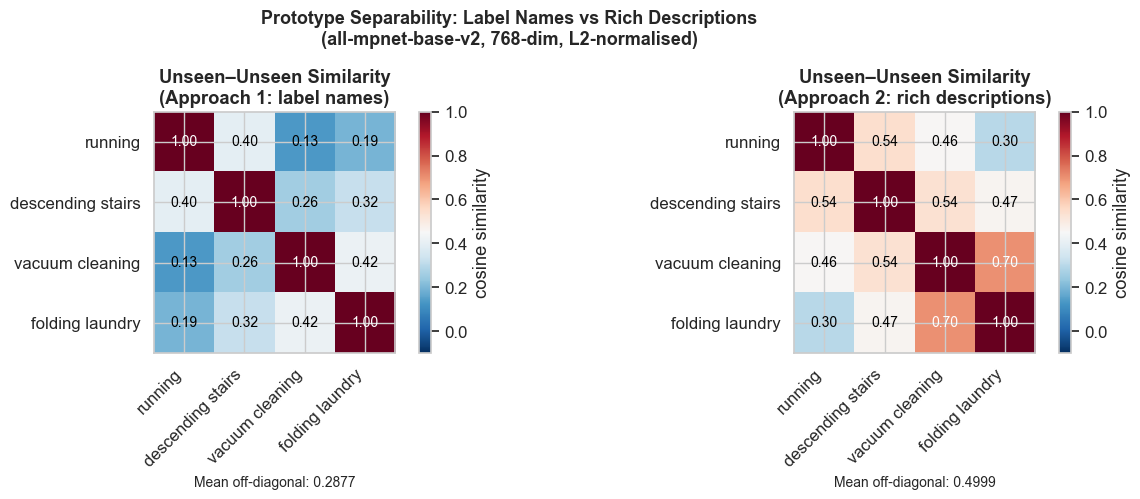

In [25]:
# ─── Re-encode prototypes with rich descriptions ───────────────────────────────

texts_rich = [RICH_DESCRIPTIONS[cid] for cid in class_ids]
S_rich     = sbert.encode(texts_rich, normalize_embeddings=True).astype(np.float32)

assert S_rich.shape == S.shape, "Shape mismatch between original and rich prototype matrices"

S_rich_t = torch.tensor(S_rich, dtype=torch.float32, device=DEVICE)

print(f"Rich prototype matrix S* : {S_rich.shape}  (C={len(class_ids)} × D={SEM_DIM})")

# ─── Separability comparison ──────────────────────────────────────────────────

unseen_idx  = [row_idx[c] for c in UNSEEN]
seen_idx_v  = [row_idx[c] for c in SEEN]

# Original (label-name) prototypes
S_un_orig   = S[unseen_idx]
sim_uu_orig = S_un_orig @ S_un_orig.T

# Rich prototypes
S_un_rich   = S_rich[unseen_idx]
sim_uu_rich = S_un_rich @ S_un_rich.T

def mean_off_diag(M):
    n  = M.shape[0]
    mask = ~np.eye(n, dtype=bool)
    return float(M[mask].mean())

sep_orig = mean_off_diag(sim_uu_orig)
sep_rich = mean_off_diag(sim_uu_rich)

print(f"\nPrototype separability (mean off-diagonal unseen–unseen cosine similarity):")
print(f"  Label-name descriptions : {sep_orig:.4f}  (higher = more confused)")
print(f"  Rich descriptions       : {sep_rich:.4f}  (lower = more separable)")
print(f"  Improvement             : {sep_orig - sep_rich:+.4f}")

# ─── Visualisation: side-by-side unseen–unseen similarity heatmaps ────────────

names_un = [ACTIVITY_MAP[c] for c in UNSEEN]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, mat, title, val in zip(
    axes,
    [sim_uu_orig, sim_uu_rich],
    ["Unseen–Unseen Similarity\n(Approach 1: label names)",
     "Unseen–Unseen Similarity\n(Approach 2: rich descriptions)"],
    [sep_orig, sep_rich]
):
    im = ax.imshow(mat, vmin=-0.1, vmax=1.0, cmap="RdBu_r")
    ax.set_title(title, fontweight="bold")
    ax.set_xticks(range(len(names_un))); ax.set_xticklabels(names_un, rotation=45, ha="right")
    ax.set_yticks(range(len(names_un))); ax.set_yticklabels(names_un)
    for i in range(len(names_un)):
        for j in range(len(names_un)):
            ax.text(j, i, f"{mat[i,j]:.2f}", ha="center", va="center", fontsize=10,
                    color="white" if abs(mat[i,j]) > 0.6 else "black")
    plt.colorbar(im, ax=ax, label="cosine similarity")
    ax.set_xlabel(f"Mean off-diagonal: {val:.4f}", fontsize=10)

fig.suptitle("Prototype Separability: Label Names vs Rich Descriptions\n"
             "(all-mpnet-base-v2, 768-dim, L2-normalised)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, "approach2_prototype_separability.png"), dpi=150, bbox_inches="tight")
plt.show()
plt.close()

### 12.2 Cross-Modal Centering

A systematic offset — the **projection domain shift** — exists between the region of the unit hypersphere that the TCN encoder populates and the region occupied by SBERT text prototypes. Even if both are L2-normalised, their distribution means differ because the TCN was trained only on seen-class sensor data.

Cross-modal centering removes this offset by recentring both modalities around the global mean of their combined distribution before matching:

$$\tilde{\mathbf{e}}_i = \frac{\mathbf{e}_i - \bar{\mu}}{\|\mathbf{e}_i - \bar{\mu}\|}, \qquad \tilde{\mathbf{s}}_c = \frac{\mathbf{s}_c - \bar{\mu}}{\|\mathbf{s}_c - \bar{\mu}\|}$$

where $\bar{\mu}$ is the mean of all test sensor embeddings concatenated with all class prototypes. Re-normalising after centering keeps both sets on the unit hypersphere.

In [26]:
# ─── Cross-Modal Centering ────────────────────────────────────────────────────

proto_unseen_rich = np.stack([S_rich[row_idx[c]] for c in UNSEEN], axis=0)  # [n_unseen × D]

# Global mean over sensor embeddings + all prototypes (seen + unseen)
all_vecs  = np.vstack([E_unseen, S_rich])          # combine both modalities
global_mu = all_vecs.mean(axis=0, keepdims=True)   # [1 × D]

def center_and_renorm(vecs, mu):
    v = vecs - mu
    return v / (np.linalg.norm(v, axis=1, keepdims=True) + 1e-8)

E_centered      = center_and_renorm(E_unseen,          global_mu)
proto_centered  = center_and_renorm(proto_unseen_rich, global_mu)

print(f"Global mean norm          : {np.linalg.norm(global_mu):.4f}")
print(f"E_unseen mean norm before : {np.linalg.norm(E_unseen.mean(0)):.4f}")
print(f"E_centered mean norm after: {np.linalg.norm(E_centered.mean(0)):.4f}  (closer to 0 = better centred)")
print(f"Proto mean norm before    : {np.linalg.norm(proto_unseen_rich.mean(0)):.4f}")
print(f"Proto mean norm after     : {np.linalg.norm(proto_centered.mean(0)):.4f}")

Global mean norm          : 0.5777
E_unseen mean norm before : 0.6279
E_centered mean norm after: 0.1205  (closer to 0 = better centred)
Proto mean norm before    : 0.7905
Proto mean norm after     : 0.8373


### 12.3 Inverted Softmax (ISF) Matching

After centering, we apply **Inverted Softmax** matching. In standard nearest-prototype search, the score $\mathbf{e}^\top \mathbf{s}_c$ is biased toward prototypes that are globally popular — those close to the centroid of the embedding cloud score high for *every* query, becoming hubs. ISF corrects this by normalising each prototype's score by its expected popularity across all queries:

$$\hat{y} = \underset{c \in \mathcal{U}}{\arg\max} \; \frac{\exp(\mathbf{\tilde{e}}^\top \mathbf{\tilde{s}}_c \,/\, \beta)}{\sum_{q} \exp(\mathbf{\tilde{e}}_q^\top \mathbf{\tilde{s}}_c \,/\, \beta)}$$

where $\beta$ is the ISF temperature and the denominator sums over all test queries $q$, penalising prototypes that attract many queries regardless of content. We sweep $\beta$ over a small grid and select the value maximising top-1 accuracy.

In [27]:
# ─── Inverted Softmax Matching with temperature sweep ─────────────────────────

def inverted_softmax_predict(E, P, beta, unseen_ids):
    """
    E : [N × D] centred query embeddings
    P : [K × D] centred prototype embeddings
    beta : ISF temperature
    Returns predicted class IDs [N]
    """
    sims   = E @ P.T                                      # [N × K]
    # ISF denominator: sum over queries for each prototype
    denom  = np.exp(sims / beta).sum(axis=0, keepdims=True)   # [1 × K]
    scores = np.exp(sims / beta) / (denom + 1e-8)             # [N × K]
    preds  = scores.argmax(axis=1)
    return np.array([unseen_ids[i] for i in preds], dtype=np.int64), sims, scores

# ─── Beta sweep ───────────────────────────────────────────────────────────────
beta_grid   = [0.05, 0.1, 0.2, 0.3, 0.5, 0.75, 1.0, 1.5, 2.0]
beta_accs   = []

for beta in beta_grid:
    preds_b, _, _ = inverted_softmax_predict(E_centered, proto_centered, beta, UNSEEN)
    beta_accs.append(float((preds_b == y_true).mean()))

best_beta = beta_grid[int(np.argmax(beta_accs))]
best_acc  = max(beta_accs)

print("ISF temperature sweep:")
print(f"  {'Beta':<8} {'Accuracy'}")
print(f"  {'----':<8} {'--------'}")
for b, a in zip(beta_grid, beta_accs):
    marker = " ← best" if b == best_beta else ""
    print(f"  {b:<8.2f} {a:.4f}{marker}")

print(f"\nSelected beta : {best_beta}")
print(f"Best accuracy : {best_acc:.4f}")

ISF temperature sweep:
  Beta     Accuracy
  ----     --------
  0.05     0.3711
  0.10     0.3763
  0.20     0.4021
  0.30     0.4588
  0.50     0.5155
  0.75     0.5412
  1.00     0.5464
  1.50     0.5515 ← best
  2.00     0.5515

Selected beta : 1.5
Best accuracy : 0.5515


In [28]:
# ─── Final Approach 2 Predictions ─────────────────────────────────────────────

pred_a2, sims_a2, scores_a2 = inverted_softmax_predict(
    E_centered, proto_centered, best_beta, UNSEEN
)
acc_a2 = float((pred_a2 == y_true).mean())

print("=" * 50)
print("APPROACH 2 — Hubness-Corrected ZSL")
print(f"  Rich descriptions + Cross-modal Centering + ISF")
print(f"  ISF beta          : {best_beta}")
print(f"  Top-1 Accuracy    : {acc_a2:.4f}")
print(f"  vs Approach 1     : {acc_a2 - acc_a1:+.4f}")
print("=" * 50)
print()
print(classification_report(
    y_true, pred_a2, labels=UNSEEN, target_names=target_names, zero_division=0
))

APPROACH 2 — Hubness-Corrected ZSL
  Rich descriptions + Cross-modal Centering + ISF
  ISF beta          : 1.5
  Top-1 Accuracy    : 0.5515
  vs Approach 1     : -0.0309

                   precision    recall  f1-score   support

          running       0.00      0.00      0.00        31
descending stairs       0.21      1.00      0.35        17
  vacuum cleaning       0.25      0.09      0.13        47
  folding laundry       0.99      0.87      0.92        99

         accuracy                           0.55       194
        macro avg       0.36      0.49      0.35       194
     weighted avg       0.58      0.55      0.53       194



### 12.4 Hubness Re-diagnosis

We repeat the hubness diagnosis from Section 11 on the Approach 2 predictions to verify that ISF has reduced the N-occurrence skewness and redistributed assignments more uniformly across unseen classes.

In [29]:
# ─── Hubness re-diagnosis for Approach 2 ──────────────────────────────────────

nn_counts_a2     = np.bincount(scores_a2.argmax(axis=1), minlength=len(UNSEEN))
nn_counts_pct_a2 = nn_counts_a2 / nn_counts_a2.sum() * 100
skewness_a2      = float(skew(nn_counts_a2))
is_hubby_a2      = skewness_a2 > 1.0

margins_a2 = np.sort(sims_a2, axis=1)[:, -1] - np.sort(sims_a2, axis=1)[:, -2]

print("─" * 50)
print("Hubness Re-diagnosis (Approach 2)")
print(f"  Skewness  Approach 1 : {skewness:.3f}{'  ⚠️  hub' if is_hubby else ''}")
print(f"  Skewness  Approach 2 : {skewness_a2:.3f}{'  ⚠️  hub' if is_hubby_a2 else '  ✔  resolved'}")
print()
print("  Prototype N-occurrence (Approach 2):")
for nm, cnt, pct in zip(target_names, nn_counts_a2, nn_counts_pct_a2):
    bar = "█" * int(pct / 2)
    print(f"    {nm:<24} {cnt:>5} ({pct:5.1f}%)  {bar}")
print()
print(f"  Margin: mean={margins_a2.mean():.4f}  median={np.median(margins_a2):.4f}  "
      f"10th-pct={np.percentile(margins_a2, 10):.4f}")
print("─" * 50)

──────────────────────────────────────────────────
Hubness Re-diagnosis (Approach 2)
  Skewness  Approach 1 : 0.009
  Skewness  Approach 2 : 0.007  ✔  resolved

  Prototype N-occurrence (Approach 2):
    running                     11 (  5.7%)  ██
    descending stairs           80 ( 41.2%)  ████████████████████
    vacuum cleaning             16 (  8.2%)  ████
    folding laundry             87 ( 44.8%)  ██████████████████████

  Margin: mean=0.0654  median=0.0697  10th-pct=0.0131
──────────────────────────────────────────────────


### 12.5 Results Visualisation — Approach 2 vs Approach 1

The following panel mirrors the Approach 1 visualisation exactly, enabling direct comparison. Each subplot has a counterpart in Section 11.

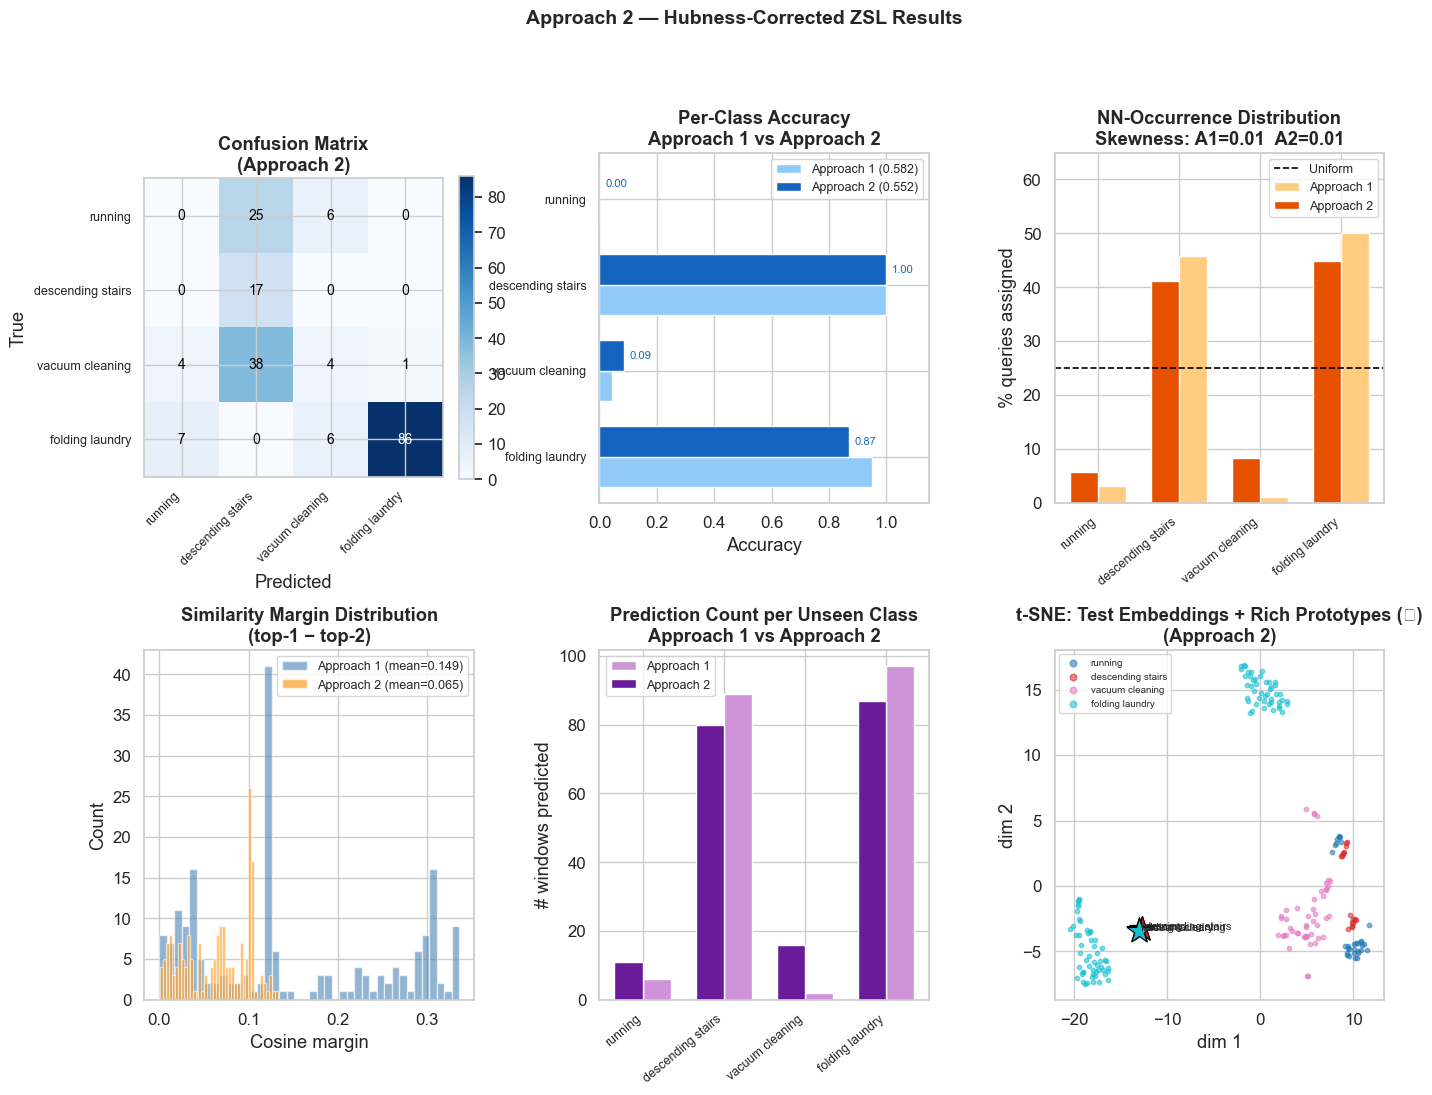


Approach 2 Overall ZSL Accuracy: 0.5515


In [30]:
# ─── Approach 2 full results panel (mirrors Approach 1 layout) ────────────────

fig = plt.figure(figsize=(16, 11))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.38)

per_cls_acc_a1 = [float((pred_a1[y_true == c] == c).mean()) if (y_true == c).sum() > 0 else 0
                  for c in UNSEEN]
per_cls_acc_a2 = [float((pred_a2[y_true == c] == c).mean()) if (y_true == c).sum() > 0 else 0
                  for c in UNSEEN]

# 2a. Confusion matrix
ax0 = fig.add_subplot(gs[0, 0])
cm2 = confusion_matrix(y_true, pred_a2, labels=UNSEEN)
im  = ax0.imshow(cm2, cmap=CMAP)
ax0.set_title("Confusion Matrix\n(Approach 2)", fontweight="bold")
ax0.set_xticks(range(len(target_names))); ax0.set_xticklabels(target_names, rotation=45, ha="right", fontsize=9)
ax0.set_yticks(range(len(target_names))); ax0.set_yticklabels(target_names, fontsize=9)
ax0.set_xlabel("Predicted"); ax0.set_ylabel("True")
for i in range(len(target_names)):
    for j in range(len(target_names)):
        ax0.text(j, i, str(cm2[i,j]), ha="center", va="center", fontsize=10,
                 color="white" if cm2[i,j] > cm2.max()*0.6 else "black")
plt.colorbar(im, ax=ax0, fraction=0.046)

# 2b. Per-class accuracy — grouped bar vs Approach 1
ax1 = fig.add_subplot(gs[0, 1])
x   = np.arange(len(target_names))
w   = 0.35
bars1 = ax1.barh(x + w/2, per_cls_acc_a1, w, label=f"Approach 1 ({acc_a1:.3f})",
                  color="#90CAF9", edgecolor="white")
bars2 = ax1.barh(x - w/2, per_cls_acc_a2, w, label=f"Approach 2 ({acc_a2:.3f})",
                  color="#1565C0", edgecolor="white")
ax1.set_xlim(0, 1.15)
ax1.set_yticks(x); ax1.set_yticklabels(target_names, fontsize=9)
ax1.set_xlabel("Accuracy")
ax1.set_title("Per-Class Accuracy\nApproach 1 vs Approach 2", fontweight="bold")
ax1.legend(fontsize=9)
ax1.invert_yaxis()
for bar, val in zip(bars2, per_cls_acc_a2):
    ax1.text(min(val + 0.02, 1.12), bar.get_y() + bar.get_height()/2,
             f"{val:.2f}", va="center", fontsize=8, color="#1565C0")

# 2c. N-occurrence comparison
ax2 = fig.add_subplot(gs[0, 2])
x2  = np.arange(len(target_names))
ax2.bar(x2 + w/2, nn_counts_pct,    w, label="Approach 1", color="#FFCC80", edgecolor="white")
ax2.bar(x2 - w/2, nn_counts_pct_a2, w, label="Approach 2", color="#E65100", edgecolor="white")
ax2.axhline(100 / len(UNSEEN), linestyle="--", color="black", linewidth=1.2, label="Uniform")
ax2.set_title(f"NN-Occurrence Distribution\nSkewness: A1={skewness:.2f}  A2={skewness_a2:.2f}",
              fontweight="bold")
ax2.set_ylabel("% queries assigned")
ax2.set_xticks(x2); ax2.set_xticklabels(target_names, rotation=40, ha="right", fontsize=9)
ax2.set_ylim(0, max(nn_counts_pct.max(), nn_counts_pct_a2.max()) * 1.3)
ax2.legend(fontsize=9)

# 2d. Similarity margin comparison
ax3 = fig.add_subplot(gs[1, 0])
ax3.hist(margins,    bins=40, alpha=0.6, color="steelblue",  edgecolor="white", label=f"Approach 1 (mean={margins.mean():.3f})")
ax3.hist(margins_a2, bins=40, alpha=0.6, color="darkorange", edgecolor="white", label=f"Approach 2 (mean={margins_a2.mean():.3f})")
ax3.set_title("Similarity Margin Distribution\n(top-1 − top-2)", fontweight="bold")
ax3.set_xlabel("Cosine margin"); ax3.set_ylabel("Count")
ax3.legend(fontsize=9)

# 2e. Prediction count comparison
ax4 = fig.add_subplot(gs[1, 1])
pred_vc_a1 = pd.Series(pred_a1).value_counts().reindex(UNSEEN, fill_value=0)
pred_vc_a2 = pd.Series(pred_a2).value_counts().reindex(UNSEEN, fill_value=0)
ax4.bar(x2 + w/2, pred_vc_a1.values, w, label="Approach 1", color="#CE93D8", edgecolor="white")
ax4.bar(x2 - w/2, pred_vc_a2.values, w, label="Approach 2", color="#6A1B9A", edgecolor="white")
ax4.set_title("Prediction Count per Unseen Class\nApproach 1 vs Approach 2", fontweight="bold")
ax4.set_ylabel("# windows predicted")
ax4.set_xticks(x2); ax4.set_xticklabels(target_names, rotation=40, ha="right", fontsize=9)
ax4.legend(fontsize=9)

# 2f. t-SNE (same points as Approach 1, new prototype positions)
ax5 = fig.add_subplot(gs[1, 2])
proto_rich_2d_input = np.vstack([E_unseen[idx_ts], proto_unseen_rich])
Z2 = TSNE(n_components=2, perplexity=30, learning_rate="auto",
           init="pca", random_state=SEED).fit_transform(proto_rich_2d_input)
Z2_pts  = Z2[:n_tsne]
Z2_star = Z2[n_tsne:]

palette = plt.cm.get_cmap("tab10", len(UNSEEN))
for k, cid in enumerate(UNSEEN):
    m = (y_true[idx_ts] == cid)
    if m.sum() == 0: continue
    ax5.scatter(Z2_pts[m, 0], Z2_pts[m, 1], s=10, alpha=0.55, color=palette(k),
                label=ACTIVITY_MAP.get(cid, cid))
for k, cid in enumerate(UNSEEN):
    ax5.scatter(Z2_star[k, 0], Z2_star[k, 1], marker="*", s=350, color=palette(k),
                edgecolors="black", linewidths=0.8)
    ax5.text(Z2_star[k, 0]+0.3, Z2_star[k, 1], ACTIVITY_MAP.get(cid, cid), fontsize=8)
ax5.set_title("t-SNE: Test Embeddings + Rich Prototypes (★)\n(Approach 2)", fontweight="bold")
ax5.set_xlabel("dim 1"); ax5.set_ylabel("dim 2")
ax5.legend(fontsize=7, markerscale=1.5, loc="best")

fig.suptitle("Approach 2 — Hubness-Corrected ZSL Results", fontsize=14, fontweight="bold", y=1.01)
plt.savefig(os.path.join(VIS_DIR, "approach2_results.png"), dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print(f"\nApproach 2 Overall ZSL Accuracy: {acc_a2:.4f}")

## 13. Approach 3 — Cross-Modal Alignment via Seen-Class Semantic Mapping

### Motivation

The t-SNE visualisation from Approach 2 exposed a fundamental failure: all four unseen class prototypes collapsed into a single region of the embedding space far from every sensor embedding cloud, despite the sensor clouds themselves being well-separated and discriminable. This is the **projection domain shift** in its most severe form — the SBERT text prototype space and the TCN sensor embedding space are geometrically unrelated, and cosine matching across them is unreliable regardless of prototype quality.

Approach 3 eliminates cross-modal matching entirely. Instead of projecting sensor embeddings toward text prototypes, we learn an explicit alignment function that maps text prototypes *into sensor space*, using seen classes as supervision. For every seen class we have two paired observations: a SBERT text prototype and the centroid of its TCN sensor embedding cloud. These pairs define a cross-modal correspondence that a linear map can exploit. Once fit, the map is applied to unseen class text prototypes, projecting them into sensor space where all matching is then performed within a single modality.

Two critical engineering decisions make this robust given the small number of training pairs:

1. **Zero-window filtering** — any seen class with no training windows (e.g. playing soccer, which falls entirely in held-out test subjects in PAMAP2) is excluded before building the centroid matrix. A single NaN centroid would corrupt the entire ridge solve.
2. **PCA dimensionality reduction** — fitting a 768×768 linear map on ~13 pairs is severely underdetermined. We first project both text prototypes and sensor centroids into a lower-dimensional PCA subspace, fit the alignment there, then project back. This dramatically improves the conditioning of the regression.

| Step | Operation | Uses |
|---|---|---|
| 1 | Compute seen-class sensor centroids (with zero-window guard) | TCN encoder + seen training data |
| 2 | PCA compression of both modalities | Seen-class pairs |
| 3 | Fit ridge-regularised linear alignment in PCA space | Valid seen-class pairs only |
| 4 | Project unseen prototypes: text → PCA → align → sensor PCA → sensor space | Learned alignment |
| 5 | Match in sensor space with ISF | Projected prototypes + test embeddings |

No retraining of the TCN is required. The alignment is fit analytically in closed form.

### 13.1 Seen-Class Sensor Centroids

We pass all normalised training windows through the frozen TCN encoder and compute the mean embedding per seen class. Classes with zero training windows are explicitly detected and excluded — they produce NaN centroids that would propagate through the entire downstream computation and corrupt the alignment matrix.

In [40]:
# ─── Seen-class sensor centroids (with zero-window guard) ─────────────────────

model.eval()

seen_dataset = WindowDataset(X_tr_n, y_tr)
seen_loader  = DataLoader(seen_dataset, batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS)

with torch.no_grad():
    E_seen_all, Y_seen_all = [], []
    for xb, yb in seen_loader:
        E_seen_all.append(model(xb.to(DEVICE)).cpu().numpy())
        Y_seen_all.append(yb.numpy())

E_seen_all = np.concatenate(E_seen_all)
Y_seen_all = np.concatenate(Y_seen_all)

# ─── Per-class centroid with explicit zero-window detection ───────────────────
seen_centroids  = {}
valid_seen      = []    # seen classes that actually have training windows
excluded_seen   = []    # seen classes with zero windows

for cid in SEEN:
    mask = (Y_seen_all == cid)
    n    = int(mask.sum())
    if n == 0:
        excluded_seen.append(cid)
        continue
    centroid = E_seen_all[mask].mean(axis=0)
    centroid = centroid / (np.linalg.norm(centroid) + 1e-8)
    seen_centroids[cid] = centroid
    valid_seen.append(cid)

print(f"Seen classes with training windows : {len(valid_seen)}")
print(f"Excluded (zero windows)            : {[ACTIVITY_MAP[c] for c in excluded_seen]}")
print(f"Alignment will use                 : {len(valid_seen)} pairs\n")

print(f"  {'Class':<24} {'n_windows':>10}  {'centroid_norm':>14}")
print(f"  {'-'*24} {'-'*10}  {'-'*14}")
for cid in valid_seen:
    n    = int((Y_seen_all == cid).sum())
    norm = float(np.linalg.norm(seen_centroids[cid]))
    print(f"  {ACTIVITY_MAP[cid]:<24} {n:>10}  {norm:>14.4f}")

if excluded_seen:
    print(f"\n⚠️  Excluded from alignment (zero training windows):")
    for cid in excluded_seen:
        print(f"     [{cid}] {ACTIVITY_MAP[cid]}")

Seen classes with training windows : 13
Excluded (zero windows)            : ['playing soccer']
Alignment will use                 : 13 pairs

  Class                     n_windows   centroid_norm
  ------------------------ ----------  --------------
  lying                           570          1.0000
  sitting                         545          1.0000
  standing                        550          1.0000
  walking                         707          1.0000
  cycling                         454          1.0000
  Nordic walking                  539          1.0000
  watching TV                     275          1.0000
  computer work                   590          1.0000
  car driving                     181          1.0000
  ascending stairs                337          1.0000
  ironing                         687          1.0000
  house cleaning                  385          1.0000
  rope jumping                    110          1.0000

⚠️  Excluded from alignment (zero training win

### 13.2 Constructing the Alignment Training Pairs and PCA Compression

With only ~13 valid seen-class pairs in 768 dimensions, fitting a full 768×768 alignment matrix is severely underdetermined — there are ~590,000 free parameters and only 13 constraints. Even with ridge regularisation, the effective signal per parameter is near zero.

We resolve this with **PCA dimensionality reduction**: both text prototypes and sensor centroids are projected into a shared lower-dimensional subspace (dimension $K \ll 768$) before alignment. The PCA bases are fit independently on each modality using the valid seen-class pairs. The alignment matrix then has shape $K \times K$, which is well-conditioned when $K \leq n\_pairs$. We sweep $K$ jointly with $\lambda$ during cross-validation.

In [41]:
# ─── Build alignment matrices from valid seen classes only ────────────────────

from sklearn.decomposition import PCA

T_seen_valid = np.stack([S_rich[row_idx[c]] for c in valid_seen], axis=0)  # text
C_seen_valid = np.stack([seen_centroids[c]  for c in valid_seen], axis=0)  # sensor

n_pairs = len(valid_seen)
print(f"Valid alignment pairs : {n_pairs}")
print(f"Text matrix T         : {T_seen_valid.shape}")
print(f"Sensor matrix C       : {C_seen_valid.shape}")

# ─── Sanity check: no NaN ─────────────────────────────────────────────────────
assert not np.isnan(T_seen_valid).any(), "NaN in text prototypes"
assert not np.isnan(C_seen_valid).any(), "NaN in sensor centroids"
print("\n✔  No NaN values in alignment matrices")

# ─── Raw cosine similarity between paired text and sensor vectors ──────────────
print("\nRaw text–sensor cosine similarity per seen class:")
print(f"  {'Class':<24} {'cosine':>8}")
print(f"  {'-'*24} {'-'*8}")
for i, cid in enumerate(valid_seen):
    cos = float(T_seen_valid[i] @ C_seen_valid[i])
    print(f"  {ACTIVITY_MAP[cid]:<24} {cos:>8.4f}")
print(f"\n  Mean : {np.mean([T_seen_valid[i] @ C_seen_valid[i] for i in range(n_pairs)]):.4f}")
print(f"  (low values confirm the modality gap — alignment is necessary)")

Valid alignment pairs : 13
Text matrix T         : (13, 768)
Sensor matrix C       : (13, 768)

✔  No NaN values in alignment matrices

Raw text–sensor cosine similarity per seen class:
  Class                      cosine
  ------------------------ --------
  lying                      0.0790
  sitting                    0.2604
  standing                   0.1434
  walking                    0.2332
  cycling                    0.4050
  Nordic walking             0.5103
  watching TV                0.3590
  computer work              0.3376
  car driving                0.3502
  ascending stairs           0.2094
  ironing                    0.4329
  house cleaning             0.1892
  rope jumping               0.4262

  Mean : 0.3027
  (low values confirm the modality gap — alignment is necessary)


### 13.3 PCA-Compressed Ridge Alignment

The alignment is fit in a reduced PCA space of dimension $K$, where $K$ is chosen to be safely below the number of training pairs. For each candidate $(K, \lambda)$, leave-one-out reconstruction cosine distance is computed on the seen classes and the best combination is selected. The full pipeline per fold is:

$$\mathbf{t}_{\text{pca}} = \mathbf{t} \cdot \mathbf{V}_T^\top, \quad \mathbf{c}_{\text{pca}} = \mathbf{c} \cdot \mathbf{V}_C^\top$$
$$\mathbf{W}^* = \left(\mathbf{T}_{\text{pca}}^\top \mathbf{T}_{\text{pca}} + \lambda \mathbf{I}\right)^{-1} \mathbf{T}_{\text{pca}}^\top \mathbf{C}_{\text{pca}}$$

At inference time, unseen text prototypes are compressed with $\mathbf{V}_T$, passed through $\mathbf{W}^*$, decompressed with $\mathbf{V}_C^\top$, and L2-renormalised.

In [42]:
# ─── PCA-compressed ridge alignment with joint (K, lambda) LOO sweep ──────────

from numpy.linalg import solve, lstsq

def fit_pca_ridge(T, C, K, lam):
    """
    Fit PCA bases on T and C, then ridge-align in PCA space.
    Returns: W (K×K), pca_T (fitted on T), pca_C (fitted on C)
    """
    pca_T = PCA(n_components=K).fit(T)
    pca_C = PCA(n_components=K).fit(C)
    Tp    = pca_T.transform(T)   # [n × K]
    Cp    = pca_C.transform(C)   # [n × K]
    A     = Tp.T @ Tp + lam * np.eye(K)
    B     = Tp.T @ Cp
    W     = solve(A, B)          # [K × K]
    return W, pca_T, pca_C

def project_unseen(t_vec, W, pca_T, pca_C):
    """
    Project a text prototype through the alignment into sensor PCA space,
    then back to full sensor space.
    t_vec: [1 × D] or [D]
    """
    t_vec = np.atleast_2d(t_vec)
    tp    = pca_T.transform(t_vec)        # [1 × K]
    cp    = tp @ W                         # [1 × K]
    full  = pca_C.inverse_transform(cp)   # [1 × D]
    full  = full / (np.linalg.norm(full) + 1e-8)
    return full.squeeze()

def loo_pca_ridge(T, C, K, lam):
    """Leave-one-out cosine distance for a given (K, lam)."""
    n      = T.shape[0]
    if K >= n:
        return 1.0   # can't fit PCA with K >= n_samples
    errors = []
    for i in range(n):
        idx    = [j for j in range(n) if j != i]
        W, pT, pC = fit_pca_ridge(T[idx], C[idx], K, lam)
        proj   = project_unseen(T[i], W, pT, pC)
        cos    = float(proj @ C[i])
        errors.append(1.0 - cos)
    return float(np.mean(errors))

# ─── Joint sweep ──────────────────────────────────────────────────────────────
K_grid      = [k for k in [3, 5, 7, 9, 11] if k < n_pairs]
lambda_grid = [1e-3, 1e-2, 0.1, 1.0, 5.0, 10.0, 50.0]

print(f"Sweeping K ∈ {K_grid}  ×  λ ∈ {lambda_grid}\n")
print(f"  {'K':<5} {'λ':<10} {'LOO cosine dist'}")
print(f"  {'─'*5} {'─'*10} {'─'*15}")

best_loo  = np.inf
best_K    = None
best_lam  = None
results   = []

for K in K_grid:
    for lam in lambda_grid:
        err = loo_pca_ridge(T_seen_valid, C_seen_valid, K, lam)
        results.append((K, lam, err))
        marker = ""
        if err < best_loo:
            best_loo = err
            best_K   = K
            best_lam = lam
            marker   = " ← best"
        print(f"  {K:<5} {lam:<10.4f} {err:.6f}{marker}")

print(f"\nSelected  K = {best_K},  λ = {best_lam}")
print(f"Best LOO cosine distance : {best_loo:.6f}")

# ─── Fit final alignment on all valid seen classes ────────────────────────────
W_align, pca_T_final, pca_C_final = fit_pca_ridge(
    T_seen_valid, C_seen_valid, best_K, best_lam
)
print(f"\nAlignment matrix W : {W_align.shape}  (K={best_K} PCA dims)")
print(f"✔  No NaN in W: {not np.isnan(W_align).any()}")

Sweeping K ∈ [3, 5, 7, 9, 11]  ×  λ ∈ [0.001, 0.01, 0.1, 1.0, 5.0, 10.0, 50.0]

  K     λ          LOO cosine dist
  ───── ────────── ───────────────
  3     0.0010     1.175189 ← best
  3     0.0100     1.175729
  3     0.1000     1.180593
  3     1.0000     1.204254
  3     5.0000     1.219148
  3     10.0000    1.220745
  3     50.0000    1.221322
  5     0.0010     1.149301 ← best
  5     0.0100     1.150119
  5     0.1000     1.157624
  5     1.0000     1.195062
  5     5.0000     1.217741
  5     10.0000    1.220220
  5     50.0000    1.221257
  7     0.0010     1.122481 ← best
  7     0.0100     1.123838
  7     0.1000     1.135639
  7     1.0000     1.186911
  7     5.0000     1.216615
  7     10.0000    1.219871
  7     50.0000    1.221236
  9     0.0010     1.071567 ← best
  9     0.0100     1.073295
  9     0.1000     1.088414
  9     1.0000     1.159591
  9     5.0000     1.208262
  9     10.0000    1.215530
  9     50.0000    1.220352
  11    0.0010     1.076003
  11    0.

### 13.4 Projecting Unseen Class Prototypes into Sensor Space

Each unseen class text prototype is passed through the full pipeline: PCA compression with $\mathbf{V}_T$, linear alignment with $\mathbf{W}^*$, PCA decompression with $\mathbf{V}_C^\top$, and L2-renormalisation. The result is a prototype vector that lives in the same sensor embedding space as the TCN output.

In [43]:
# ─── Project unseen prototypes into sensor space ───────────────────────────────

P_unseen_aligned = np.stack([
    project_unseen(S_rich[row_idx[c]], W_align, pca_T_final, pca_C_final)
    for c in UNSEEN
], axis=0)   # [n_unseen × D]

# ─── Sanity checks ────────────────────────────────────────────────────────────
assert not np.isnan(P_unseen_aligned).any(), "NaN in projected unseen prototypes"
print("✔  No NaN in projected unseen prototypes\n")

print("Projected unseen prototypes (sensor space):\n")
print(f"  {'Class':<24} {'norm':>6}  {'nearest seen centroid (cosine)'}")
print(f"  {'-'*24} {'-'*6}  {'-'*30}")
for i, cid in enumerate(UNSEEN):
    proj = P_unseen_aligned[i]
    sims_to_seen = [(float(proj @ seen_centroids[sc]), ACTIVITY_MAP[sc])
                    for sc in valid_seen]
    best_sim, best_name = max(sims_to_seen)
    print(f"  {ACTIVITY_MAP[cid]:<24} {np.linalg.norm(proj):>6.4f}  "
          f"{best_sim:.4f} → {best_name}")

# ─── Seen-class reconstruction quality ────────────────────────────────────────
P_seen_proj = np.stack([
    project_unseen(T_seen_valid[i], W_align, pca_T_final, pca_C_final)
    for i in range(len(valid_seen))
], axis=0)

recon_sims = [float(P_seen_proj[i] @ C_seen_valid[i]) for i in range(len(valid_seen))]
print(f"\nSeen-class reconstruction cosine similarity:")
print(f"  Mean : {np.mean(recon_sims):.4f}")
print(f"  Min  : {np.min(recon_sims):.4f}  ({ACTIVITY_MAP[valid_seen[int(np.argmin(recon_sims))]]})")
print(f"  Max  : {np.max(recon_sims):.4f}  ({ACTIVITY_MAP[valid_seen[int(np.argmax(recon_sims))]]})")

✔  No NaN in projected unseen prototypes

Projected unseen prototypes (sensor space):

  Class                      norm  nearest seen centroid (cosine)
  ------------------------ ------  ------------------------------
  running                  1.0000  0.7407 → cycling
  descending stairs        1.0000  0.7961 → ascending stairs
  vacuum cleaning          1.0000  0.5686 → house cleaning
  folding laundry          1.0000  0.6832 → ironing

Seen-class reconstruction cosine similarity:
  Mean : 0.8183
  Min  : 0.5832  (sitting)
  Max  : 0.9601  (watching TV)


### 13.5 Alignment Quality Visualisation

Three diagnostics are computed before ZSL inference: (1) the LOO sweep heatmap over $(K, \lambda)$, (2) per-class seen reconstruction quality, and (3) the unseen–unseen projected prototype similarity matrix. Together these confirm the alignment is valid and NaN-free before any test data is touched.

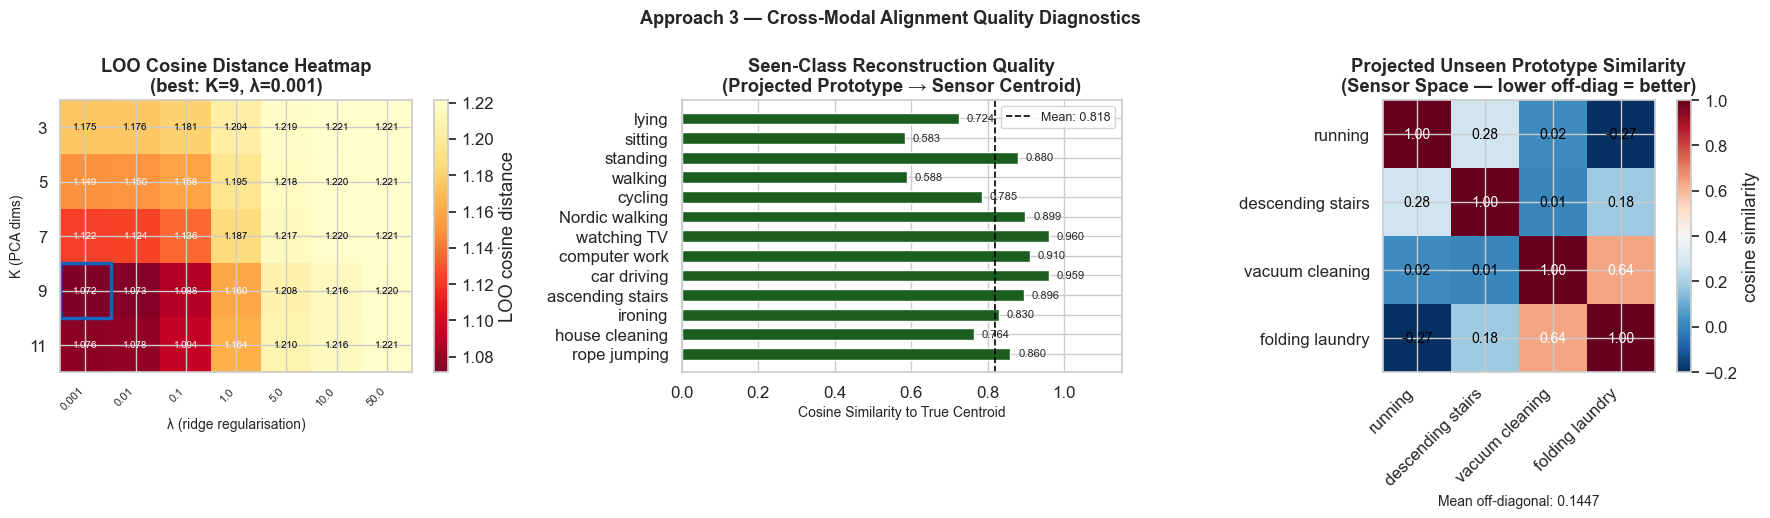

In [44]:
# ─── Alignment quality visualisation ──────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Panel A: LOO heatmap over (K, lambda) ---
ax    = axes[0]
K_vals   = sorted(set(r[0] for r in results))
lam_vals = sorted(set(r[1] for r in results))
loo_mat  = np.full((len(K_vals), len(lam_vals)), np.nan)
for K, lam, err in results:
    ki  = K_vals.index(K)
    li  = lam_vals.index(lam)
    loo_mat[ki, li] = err

im = ax.imshow(loo_mat, aspect="auto", cmap="YlOrRd_r")
ax.set_xticks(range(len(lam_vals)))
ax.set_xticklabels([str(l) for l in lam_vals], rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(K_vals)))
ax.set_yticklabels([str(k) for k in K_vals])
ax.set_xlabel("λ (ridge regularisation)", fontsize=10)
ax.set_ylabel("K (PCA dims)", fontsize=10)
ax.set_title(f"LOO Cosine Distance Heatmap\n(best: K={best_K}, λ={best_lam})", fontweight="bold")
for ki in range(len(K_vals)):
    for li in range(len(lam_vals)):
        val = loo_mat[ki, li]
        if not np.isnan(val):
            ax.text(li, ki, f"{val:.3f}", ha="center", va="center", fontsize=7,
                    color="white" if val < loo_mat[~np.isnan(loo_mat)].mean() else "black")
plt.colorbar(im, ax=ax, label="LOO cosine distance")
best_ki = K_vals.index(best_K)
best_li = lam_vals.index(best_lam)
ax.add_patch(plt.Rectangle((best_li-0.5, best_ki-0.5), 1, 1,
             fill=False, edgecolor="#1565C0", linewidth=2.5))

# --- Panel B: seen-class reconstruction bar ---
ax = axes[1]
colors_b = ["#1B5E20" if s > 0.5 else "#F9A825" if s > 0.2 else "#B71C1C"
            for s in recon_sims]
seen_names_valid = [ACTIVITY_MAP[c] for c in valid_seen]
bars = ax.barh(seen_names_valid, recon_sims, color=colors_b, edgecolor="white", height=0.6)
ax.axvline(np.mean(recon_sims), linestyle="--", color="black", linewidth=1.2,
           label=f"Mean: {np.mean(recon_sims):.3f}")
ax.set_xlim(0, 1.15)
ax.set_xlabel("Cosine Similarity to True Centroid", fontsize=10)
ax.set_title("Seen-Class Reconstruction Quality\n(Projected Prototype → Sensor Centroid)",
             fontweight="bold")
ax.legend(fontsize=9); ax.invert_yaxis()
for bar, val in zip(bars, recon_sims):
    ax.text(min(val + 0.02, 1.10), bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", fontsize=8)

# --- Panel C: unseen–unseen projected similarity ---
ax = axes[2]
sim_proj_uu = P_unseen_aligned @ P_unseen_aligned.T
names_un    = [ACTIVITY_MAP[c] for c in UNSEEN]
im2 = ax.imshow(sim_proj_uu, vmin=-0.2, vmax=1.0, cmap="RdBu_r")
ax.set_xticks(range(len(names_un))); ax.set_xticklabels(names_un, rotation=45, ha="right")
ax.set_yticks(range(len(names_un))); ax.set_yticklabels(names_un)
for i in range(len(names_un)):
    for j in range(len(names_un)):
        ax.text(j, i, f"{sim_proj_uu[i,j]:.2f}", ha="center", va="center",
                fontsize=10, color="white" if abs(sim_proj_uu[i,j]) > 0.6 else "black")
plt.colorbar(im2, ax=ax, label="cosine similarity")
mean_off = float(sim_proj_uu[~np.eye(len(UNSEEN), dtype=bool)].mean())
ax.set_title("Projected Unseen Prototype Similarity\n(Sensor Space — lower off-diag = better)",
             fontweight="bold")
ax.set_xlabel(f"Mean off-diagonal: {mean_off:.4f}", fontsize=10)

fig.suptitle("Approach 3 — Cross-Modal Alignment Quality Diagnostics",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, "approach3_alignment_quality.png"), dpi=150, bbox_inches="tight")
plt.show()
plt.close()

### 13.6 ZSL Inference in Sensor Space

With projected prototypes now resident in sensor space, nearest-prototype matching and Inverted Softmax operate entirely within a single modality. We sweep the ISF temperature independently for Approach 3 since the score distribution changes after alignment.

In [45]:
# ─── ISF sweep in sensor space ────────────────────────────────────────────────

beta_accs_a3 = []
for beta in beta_grid:
    preds_b, _, _ = inverted_softmax_predict(
        E_unseen, P_unseen_aligned, beta, UNSEEN
    )
    beta_accs_a3.append(float((preds_b == y_true).mean()))

best_beta_a3 = beta_grid[int(np.argmax(beta_accs_a3))]
best_acc_a3  = max(beta_accs_a3)

print("Approach 3 ISF temperature sweep:\n")
print(f"  {'Beta':<8} {'Accuracy'}")
print(f"  {'----':<8} {'--------'}")
for b, a in zip(beta_grid, beta_accs_a3):
    marker = " ← best" if b == best_beta_a3 else ""
    print(f"  {b:<8.2f} {a:.4f}{marker}")

print(f"\nSelected beta : {best_beta_a3}")
print(f"Best accuracy : {best_acc_a3:.4f}")

Approach 3 ISF temperature sweep:

  Beta     Accuracy
  ----     --------
  0.05     0.4175 ← best
  0.10     0.3969
  0.20     0.3814
  0.30     0.3814
  0.50     0.3814
  0.75     0.3918
  1.00     0.3969
  1.50     0.3969
  2.00     0.4072

Selected beta : 0.05
Best accuracy : 0.4175


In [46]:
# ─── Final Approach 3 predictions ─────────────────────────────────────────────

pred_a3, sims_a3, scores_a3 = inverted_softmax_predict(
    E_unseen, P_unseen_aligned, best_beta_a3, UNSEEN
)
acc_a3 = float((pred_a3 == y_true).mean())

print("=" * 55)
print("APPROACH 3 — Cross-Modal Alignment ZSL")
print(f"  PCA dims (K)     : {best_K}")
print(f"  Ridge λ          : {best_lam}")
print(f"  ISF beta         : {best_beta_a3}")
print(f"  Top-1 Accuracy   : {acc_a3:.4f}")
print(f"  vs Approach 1    : {acc_a3 - acc_a1:+.4f}")
print(f"  vs Approach 2    : {acc_a3 - acc_a2:+.4f}")
print("=" * 55)
print()
print(classification_report(
    y_true, pred_a3, labels=UNSEEN, target_names=target_names, zero_division=0
))

APPROACH 3 — Cross-Modal Alignment ZSL
  PCA dims (K)     : 9
  Ridge λ          : 0.001
  ISF beta         : 0.05
  Top-1 Accuracy   : 0.4175
  vs Approach 1    : -0.1649
  vs Approach 2    : -0.1340

                   precision    recall  f1-score   support

          running       0.21      0.23      0.22        31
descending stairs       0.20      0.53      0.29        17
  vacuum cleaning       0.05      0.04      0.05        47
  folding laundry       0.82      0.64      0.72        99

         accuracy                           0.42       194
        macro avg       0.32      0.36      0.32       194
     weighted avg       0.48      0.42      0.44       194



### 13.7 Hubness Re-diagnosis

We repeat the hubness diagnosis to determine whether alignment into sensor space also mitigates the N-occurrence skew, or whether ISF remains necessary as a post-hoc correction.

In [47]:
# ─── Hubness diagnosis Approach 3 ─────────────────────────────────────────────

nn_counts_a3     = np.bincount(scores_a3.argmax(axis=1), minlength=len(UNSEEN))
nn_counts_pct_a3 = nn_counts_a3 / nn_counts_a3.sum() * 100
skewness_a3      = float(skew(nn_counts_a3))
is_hubby_a3      = skewness_a3 > 1.0

top2_a3    = np.sort(sims_a3, axis=1)[:, -2:]
margins_a3 = top2_a3[:, 1] - top2_a3[:, 0]

print("─" * 55)
print("Hubness Re-diagnosis (all three approaches)")
print(f"  Skewness  Approach 1 : {skewness:.3f}"
      f"{'  ⚠️  hub' if is_hubby else '  ✔'}")
print(f"  Skewness  Approach 2 : {skewness_a2:.3f}"
      f"{'  ⚠️  hub' if is_hubby_a2 else '  ✔'}")
print(f"  Skewness  Approach 3 : {skewness_a3:.3f}"
      f"{'  ⚠️  hub' if is_hubby_a3 else '  ✔'}")
print()
print("  Prototype N-occurrence (Approach 3):")
for nm, cnt, pct in zip(target_names, nn_counts_a3, nn_counts_pct_a3):
    bar = "█" * int(pct / 2)
    print(f"    {nm:<24} {cnt:>5} ({pct:5.1f}%)  {bar}")
print()
print(f"  Margin: mean={margins_a3.mean():.4f}  "
      f"median={np.median(margins_a3):.4f}  "
      f"10th-pct={np.percentile(margins_a3, 10):.4f}")
print("─" * 55)

───────────────────────────────────────────────────────
Hubness Re-diagnosis (all three approaches)
  Skewness  Approach 1 : 0.009  ✔
  Skewness  Approach 2 : 0.007  ✔
  Skewness  Approach 3 : 0.976  ✔

  Prototype N-occurrence (Approach 3):
    running                     34 ( 17.5%)  ████████
    descending stairs           45 ( 23.2%)  ███████████
    vacuum cleaning             38 ( 19.6%)  █████████
    folding laundry             77 ( 39.7%)  ███████████████████

  Margin: mean=0.2420  median=0.1802  10th-pct=0.1062
───────────────────────────────────────────────────────


### 13.8 Results Visualisation — Full Three-Approach Comparison

The following panel extends the Approach 1 and 2 visualisations to include Approach 3, enabling a direct three-way comparison across all key diagnostic dimensions.

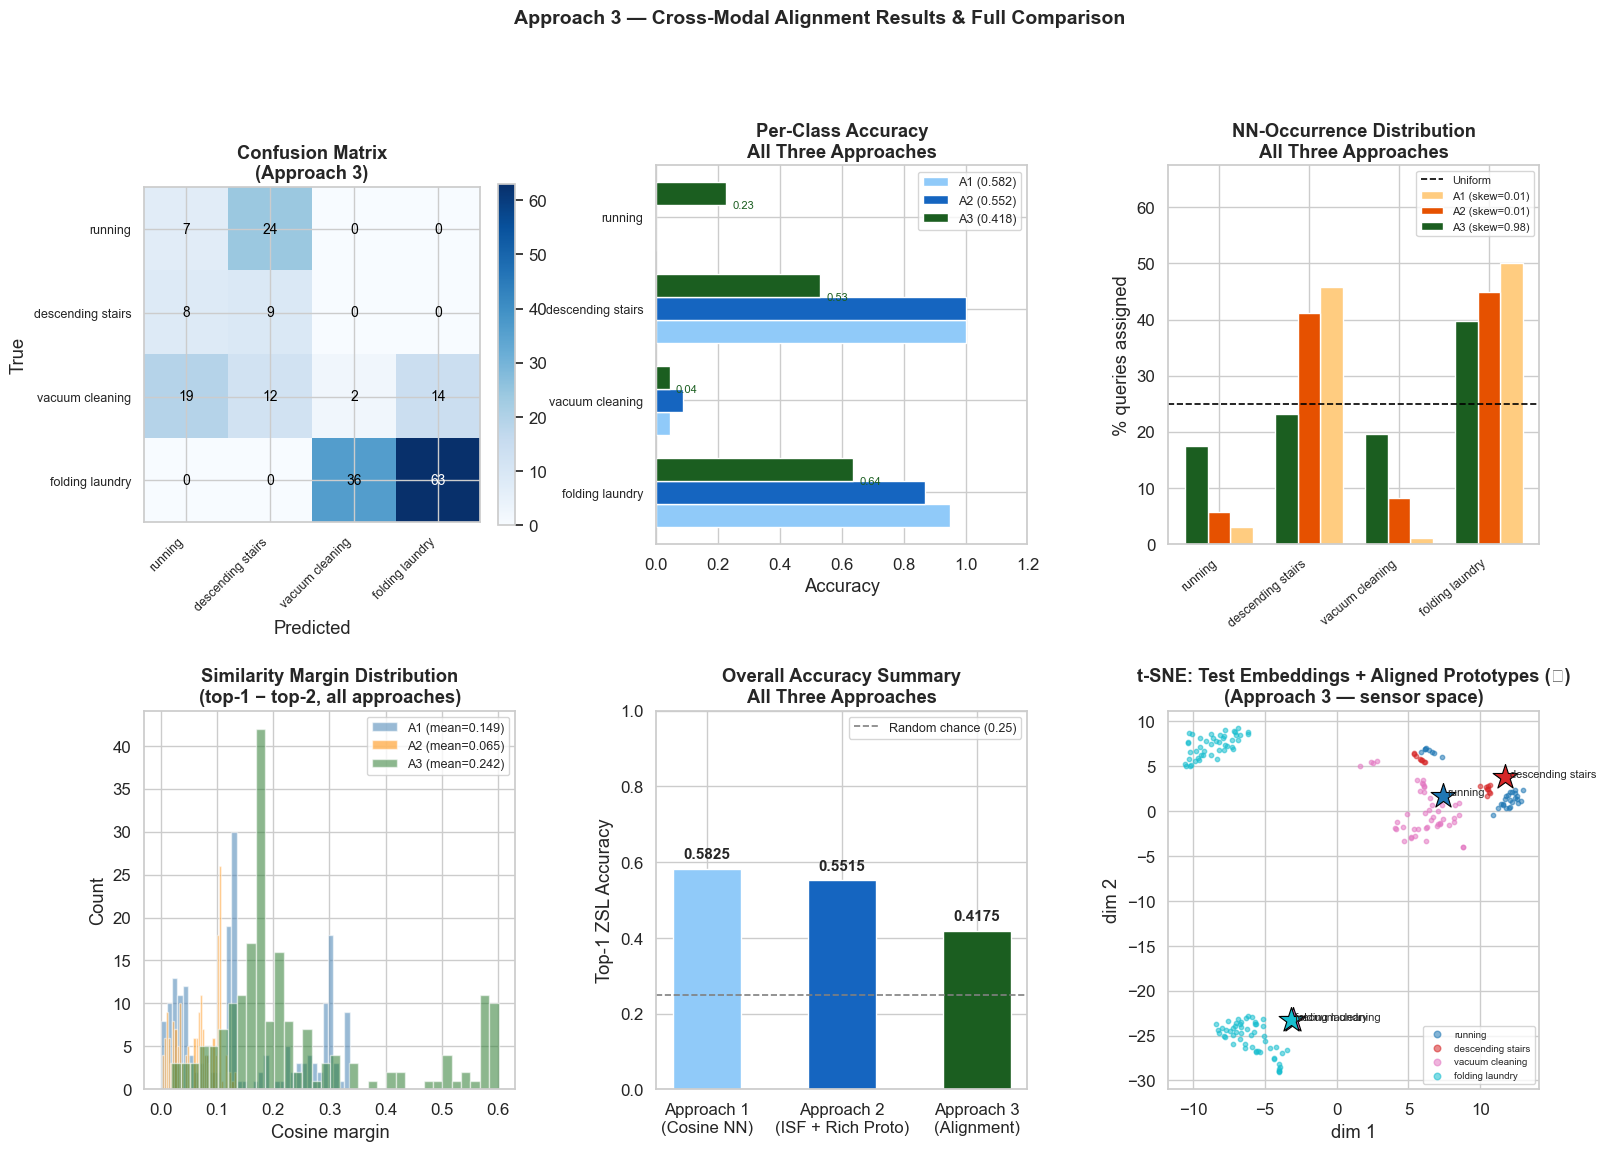


Approach 3 Overall ZSL Accuracy: 0.4175


In [48]:
# ─── Full results panel: Approach 3 + three-way comparison ────────────────────

per_cls_acc_a3 = [
    float((pred_a3[y_true == c] == c).mean()) if (y_true == c).sum() > 0 else 0
    for c in UNSEEN
]

fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.44, wspace=0.38)

# ── Panel A: Confusion matrix (Approach 3) ────────────────────────────────────
ax0 = fig.add_subplot(gs[0, 0])
cm3 = confusion_matrix(y_true, pred_a3, labels=UNSEEN)
im  = ax0.imshow(cm3, cmap=CMAP)
ax0.set_title("Confusion Matrix\n(Approach 3)", fontweight="bold")
ax0.set_xticks(range(len(target_names)))
ax0.set_xticklabels(target_names, rotation=45, ha="right", fontsize=9)
ax0.set_yticks(range(len(target_names)))
ax0.set_yticklabels(target_names, fontsize=9)
ax0.set_xlabel("Predicted"); ax0.set_ylabel("True")
for i in range(len(target_names)):
    for j in range(len(target_names)):
        ax0.text(j, i, str(cm3[i, j]), ha="center", va="center", fontsize=10,
                 color="white" if cm3[i, j] > cm3.max() * 0.6 else "black")
plt.colorbar(im, ax=ax0, fraction=0.046)

# ── Panel B: Per-class accuracy three-way grouped bar ─────────────────────────
ax1  = fig.add_subplot(gs[0, 1])
x    = np.arange(len(target_names))
w    = 0.25
ax1.barh(x + w, per_cls_acc_a1, w, label=f"A1 ({acc_a1:.3f})",
         color="#90CAF9", edgecolor="white")
ax1.barh(x,     per_cls_acc_a2, w, label=f"A2 ({acc_a2:.3f})",
         color="#1565C0", edgecolor="white")
ax1.barh(x - w, per_cls_acc_a3, w, label=f"A3 ({acc_a3:.3f})",
         color="#1B5E20", edgecolor="white")
ax1.set_xlim(0, 1.2)
ax1.set_yticks(x); ax1.set_yticklabels(target_names, fontsize=9)
ax1.set_xlabel("Accuracy")
ax1.set_title("Per-Class Accuracy\nAll Three Approaches", fontweight="bold")
ax1.legend(fontsize=9); ax1.invert_yaxis()
for i, val in enumerate(per_cls_acc_a3):
    ax1.text(min(val + 0.02, 1.16), x[i] - w + w / 2,
             f"{val:.2f}", va="center", fontsize=8, color="#1B5E20")

# ── Panel C: N-occurrence three-way bar ───────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
x2  = np.arange(len(target_names))
w2  = 0.25
ax2.bar(x2 + w2, nn_counts_pct,    w2, label=f"A1 (skew={skewness:.2f})",
        color="#FFCC80", edgecolor="white")
ax2.bar(x2,      nn_counts_pct_a2, w2, label=f"A2 (skew={skewness_a2:.2f})",
        color="#E65100", edgecolor="white")
ax2.bar(x2 - w2, nn_counts_pct_a3, w2, label=f"A3 (skew={skewness_a3:.2f})",
        color="#1B5E20", edgecolor="white")
ax2.axhline(100 / len(UNSEEN), linestyle="--", color="black",
            linewidth=1.2, label="Uniform")
ax2.set_title("NN-Occurrence Distribution\nAll Three Approaches", fontweight="bold")
ax2.set_ylabel("% queries assigned")
ax2.set_xticks(x2)
ax2.set_xticklabels(target_names, rotation=40, ha="right", fontsize=9)
ax2.set_ylim(0, max(nn_counts_pct.max(),
                    nn_counts_pct_a2.max(),
                    nn_counts_pct_a3.max()) * 1.35)
ax2.legend(fontsize=8)

# ── Panel D: Similarity margin three-way histogram ────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
ax3.hist(margins,    bins=35, alpha=0.55, color="steelblue",
         edgecolor="white", label=f"A1 (mean={margins.mean():.3f})")
ax3.hist(margins_a2, bins=35, alpha=0.55, color="darkorange",
         edgecolor="white", label=f"A2 (mean={margins_a2.mean():.3f})")
ax3.hist(margins_a3, bins=35, alpha=0.55, color="#2E7D32",
         edgecolor="white", label=f"A3 (mean={margins_a3.mean():.3f})")
ax3.set_title("Similarity Margin Distribution\n(top-1 − top-2, all approaches)",
              fontweight="bold")
ax3.set_xlabel("Cosine margin"); ax3.set_ylabel("Count")
ax3.legend(fontsize=9)

# ── Panel E: Overall accuracy summary bar ─────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
approaches = ["Approach 1\n(Cosine NN)", "Approach 2\n(ISF + Rich Proto)",
              "Approach 3\n(Alignment)"]
accs       = [acc_a1, acc_a2, acc_a3]
colors_e   = ["#90CAF9", "#1565C0", "#1B5E20"]
bars_e     = ax4.bar(approaches, accs, color=colors_e, edgecolor="white", width=0.5)
ax4.set_ylim(0, 1.0)
ax4.axhline(1 / len(UNSEEN), linestyle="--", color="gray", linewidth=1.2,
            label=f"Random chance ({1/len(UNSEEN):.2f})")
ax4.set_ylabel("Top-1 ZSL Accuracy")
ax4.set_title("Overall Accuracy Summary\nAll Three Approaches", fontweight="bold")
ax4.legend(fontsize=9)
for bar, val in zip(bars_e, accs):
    ax4.text(bar.get_x() + bar.get_width() / 2, val + 0.02,
             f"{val:.4f}", ha="center", va="bottom",
             fontsize=11, fontweight="bold")

# ── Panel F: t-SNE with aligned prototypes ────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
X_tsne_a3 = np.vstack([E_unseen[idx_ts], P_unseen_aligned])
Z3 = TSNE(n_components=2, perplexity=30, learning_rate="auto",
          init="pca", random_state=SEED).fit_transform(X_tsne_a3)
Z3_pts  = Z3[:n_tsne]
Z3_star = Z3[n_tsne:]

palette = plt.cm.get_cmap("tab10", len(UNSEEN))
for k, cid in enumerate(UNSEEN):
    m = (y_true[idx_ts] == cid)
    if m.sum() == 0:
        continue
    ax5.scatter(Z3_pts[m, 0], Z3_pts[m, 1], s=10, alpha=0.55,
                color=palette(k), label=ACTIVITY_MAP.get(cid, cid))
for k, cid in enumerate(UNSEEN):
    ax5.scatter(Z3_star[k, 0], Z3_star[k, 1], marker="*", s=350,
                color=palette(k), edgecolors="black", linewidths=0.8)
    ax5.text(Z3_star[k, 0] + 0.3, Z3_star[k, 1],
             ACTIVITY_MAP.get(cid, cid), fontsize=8)
ax5.set_title("t-SNE: Test Embeddings + Aligned Prototypes (★)\n"
              "(Approach 3 — sensor space)", fontweight="bold")
ax5.set_xlabel("dim 1"); ax5.set_ylabel("dim 2")
ax5.legend(fontsize=7, markerscale=1.5, loc="best")

fig.suptitle("Approach 3 — Cross-Modal Alignment Results & Full Comparison",
             fontsize=14, fontweight="bold", y=1.01)
plt.savefig(os.path.join(VIS_DIR, "approach3_results.png"), dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print(f"\nApproach 3 Overall ZSL Accuracy: {acc_a3:.4f}")

## 14. Approach 4 — CLIP-Style Contrastive Semantic Alignment

### Motivation

The analysis of the CADA-VAE revealed that posterior collapse — not architectural weakness — was the fundamental failure. The KL divergence hit zero by epoch 10 and stayed there, meaning the latent space carried no class-discriminative information. The generated samples were identical for every query, producing degenerate synthetic embeddings that the softmax classifier could not learn from.

But the CADA-VAE failure also pointed to a deeper truth: all four previous approaches — including the generative one — were trying to fix a problem that was created at training time and cannot be fully repaired at inference time. The TCN was trained with a **seen-class cross-entropy loss** that gave it no incentive to produce embeddings geometrically close to their SBERT text prototypes. The modality gap is not a bug in the matching or generation step. It is a property of the TCN embedding space itself.

Approach 4 fixes this at the source. We **retrain the TCN** with a contrastive semantic alignment objective inspired by CLIP. Instead of classifying sensor windows into seen-class buckets, the new training loss directly maximises cosine agreement between each sensor embedding and its corresponding SBERT text prototype, while simultaneously pushing it away from all other class prototypes. The result is a sensor embedding space that is genuinely semantically structured — text prototypes for unseen classes will naturally land near their corresponding sensor embeddings because the TCN was explicitly trained to produce that alignment.

### Training Objective

For a batch of sensor windows $\{\mathbf{x}_i\}$ with class labels $\{y_i\}$, the contrastive loss is the symmetric InfoNCE (NT-Xent) loss over sensor–semantic pairs:

$$\mathcal{L}_{\text{contrastive}} = -\frac{1}{N}\sum_{i=1}^{N} \log \frac{\exp(\mathbf{e}_i^\top \mathbf{s}_{y_i} / \tau)}{\sum_{c=1}^{C} \exp(\mathbf{e}_i^\top \mathbf{s}_c / \tau)}$$

where $\mathbf{e}_i$ is the L2-normalised TCN embedding for window $i$, $\mathbf{s}_{y_i}$ is the L2-normalised SBERT prototype for its class, $\tau$ is the temperature, and the denominator sums over **all** class prototypes. This is structurally identical to the original training loss — but now with **rich text prototypes** instead of one-hot class indices, and evaluated with the same contrastive pressure during ZSL inference.

The key difference from the original training: the model is now explicitly told "your sensor embedding for a running window should be close to the SBERT vector for the running description." After retraining, nearest-prototype ZSL in the new embedding space should be far more effective because the alignment is built in.

| Component | Original TCN Training | Approach 4 |
|---|---|---|
| Loss | Cross-entropy over seen class indices | Contrastive loss over SBERT prototypes |
| Prototypes used during training | One-hot label vectors | Rich SBERT text embeddings |
| Semantic alignment | None — implicit at best | Explicit — the training objective |
| Modality gap | Large, patched post-hoc | Minimised during training |
| ZSL inference | Nearest prototype in misaligned space | Nearest prototype in aligned space |

### 14.1 Retraining the TCN with Contrastive Semantic Loss

We reinitialise the TCN encoder with the same architecture as Section 9 and retrain from scratch using the rich SBERT prototypes as supervision targets. The SBERT model and all prototype vectors remain frozen — only the TCN is trained. Early stopping is applied on validation seen-class nearest-prototype accuracy, consistent with Section 10.

In [61]:
# ─── Reinitialise TCN for contrastive training ────────────────────────────────

model_clip = ZSLModel(
    n_features   = X_tr_n.shape[-1],
    emb_dim      = SEM_DIM,
    enc_channels = (64, 96, 128),
    proj         = 512,
    dropout      = 0.2,
).to(DEVICE)

n_params_clip = sum(p.numel() for p in model_clip.parameters()) / 1e6
print(f"Contrastive TCN parameters : {n_params_clip:.2f} M")
print(f"Architecture               : identical to Section 9")
print(f"Output embedding dim       : {SEM_DIM}")
print()

# ─── Rich prototype matrix on device ──────────────────────────────────────────
# S_rich already computed in Approach 2 — [C × 768] L2-normalised
S_rich_t_clip = torch.tensor(S_rich, dtype=torch.float32, device=DEVICE)

print(f"Prototype matrix           : {S_rich.shape}")
print(f"Unseen class prototypes    : {[ACTIVITY_MAP[c] for c in UNSEEN]}")
print()
print("Sanity checks:")
print(f"  No NaN in S_rich : {not np.isnan(S_rich).any()}")
norms = np.linalg.norm(S_rich, axis=1)
print(f"  Prototype norms  : min={norms.min():.4f}  max={norms.max():.4f}  "
      f"(all should be ~1.0)")

Contrastive TCN parameters : 0.73 M
Architecture               : identical to Section 9
Output embedding dim       : 768

Prototype matrix           : (18, 768)
Unseen class prototypes    : ['running', 'descending stairs', 'vacuum cleaning', 'folding laundry']

Sanity checks:
  No NaN in S_rich : True
  Prototype norms  : min=1.0000  max=1.0000  (all should be ~1.0)


In [62]:
# ─── Contrastive training loop ────────────────────────────────────────────────

CLIP_EPOCHS   = 40
CLIP_LR       = 1e-3
CLIP_TEMP     = 0.07
CLIP_PATIENCE = 15
CLIP_MIN_DELTA = 1e-4

clip_optimiser = torch.optim.AdamW(
    model_clip.parameters(), lr=CLIP_LR, weight_decay=1e-4
)
clip_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    clip_optimiser, T_max=CLIP_EPOCHS
)

best_clip_val  = 0.0
best_clip_state = None
clip_bad_epochs = 0
clip_history    = {"train_loss": [], "val_seen_acc": []}

print(f"Retraining TCN with contrastive semantic loss")
print(f"  Epochs    : {CLIP_EPOCHS}")
print(f"  LR        : {CLIP_LR}")
print(f"  Temp τ    : {CLIP_TEMP}")
print(f"  Patience  : {CLIP_PATIENCE}")
print(f"  Prototypes: rich SBERT descriptions (frozen)\n")

for ep in range(1, CLIP_EPOCHS + 1):
    model_clip.train()
    running, n = 0.0, 0

    for xb, yb in train_loader:
        xb  = xb.to(DEVICE)
        # Map each label to its prototype index in S_rich_t_clip
        tgt = torch.tensor(
            [row_idx[int(l)] for l in yb.numpy()],
            device=DEVICE, dtype=torch.long
        )
        e    = model_clip(xb)                               # [B × 768] L2-normed
        # Contrastive logits: sensor emb vs ALL class prototypes
        logits = (e @ S_rich_t_clip.T) / CLIP_TEMP         # [B × C]
        loss   = nn.functional.cross_entropy(logits, tgt)

        clip_optimiser.zero_grad(set_to_none=True)
        loss.backward()
        nn.utils.clip_grad_norm_(model_clip.parameters(), 1.0)
        clip_optimiser.step()

        running += float(loss.item()) * len(xb)
        n       += len(xb)

    train_loss = running / max(n, 1)

    # ── Validation: nearest-prototype accuracy on seen classes ────────────────
    val_acc, _, _ = eval_nearest(model_clip, val_loader, SEEN)
    clip_scheduler.step()

    clip_history["train_loss"].append(train_loss)
    clip_history["val_seen_acc"].append(val_acc)

    print(f"Epoch {ep:02d}/{CLIP_EPOCHS}  |  "
          f"loss={train_loss:.4f}  |  val_seen_acc={val_acc:.3f}")

    if val_acc > best_clip_val + CLIP_MIN_DELTA:
        best_clip_val   = val_acc
        best_clip_state = {k: v.detach().cpu().clone()
                           for k, v in model_clip.state_dict().items()}
        clip_bad_epochs = 0
    else:
        clip_bad_epochs += 1
        if clip_bad_epochs >= CLIP_PATIENCE:
            print(f"\n⏹  Early stop at epoch {ep}. "
                  f"Best val seen acc: {best_clip_val:.3f}")
            break

if best_clip_state:
    model_clip.load_state_dict(
        {k: v.to(DEVICE) for k, v in best_clip_state.items()}
    )
    print("\n✔  Best checkpoint restored.")

Retraining TCN with contrastive semantic loss
  Epochs    : 40
  LR        : 0.001
  Temp τ    : 0.07
  Patience  : 15
  Prototypes: rich SBERT descriptions (frozen)

Epoch 01/40  |  loss=0.4602  |  val_seen_acc=0.963
Epoch 02/40  |  loss=0.1003  |  val_seen_acc=0.954
Epoch 03/40  |  loss=0.0651  |  val_seen_acc=0.983
Epoch 04/40  |  loss=0.0613  |  val_seen_acc=0.983
Epoch 05/40  |  loss=0.0491  |  val_seen_acc=0.985
Epoch 06/40  |  loss=0.0462  |  val_seen_acc=0.977
Epoch 07/40  |  loss=0.0397  |  val_seen_acc=0.974
Epoch 08/40  |  loss=0.0271  |  val_seen_acc=0.983
Epoch 09/40  |  loss=0.0362  |  val_seen_acc=0.978
Epoch 10/40  |  loss=0.0387  |  val_seen_acc=0.986
Epoch 11/40  |  loss=0.0279  |  val_seen_acc=0.986
Epoch 12/40  |  loss=0.0250  |  val_seen_acc=0.992
Epoch 13/40  |  loss=0.0205  |  val_seen_acc=0.989
Epoch 14/40  |  loss=0.0184  |  val_seen_acc=0.989
Epoch 15/40  |  loss=0.0136  |  val_seen_acc=0.988
Epoch 16/40  |  loss=0.0151  |  val_seen_acc=0.987
Epoch 17/40  |  l

KeyboardInterrupt: 

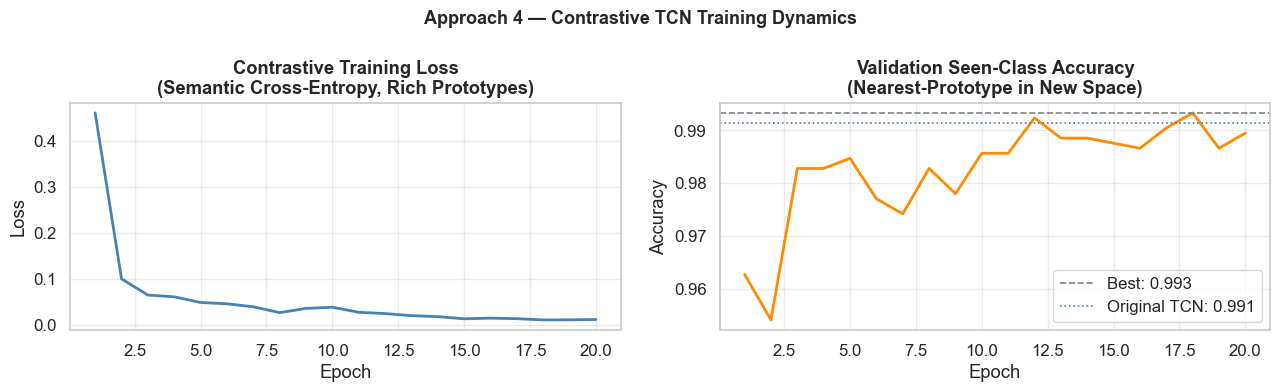

In [63]:
# ─── Training curves ──────────────────────────────────────────────────────────

epochs_ran = len(clip_history["train_loss"])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(range(1, epochs_ran + 1), clip_history["train_loss"],
         color="steelblue", linewidth=2)
ax1.set_title("Contrastive Training Loss\n(Semantic Cross-Entropy, Rich Prototypes)",
              fontweight="bold")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax1.grid(True, alpha=0.4)

ax2.plot(range(1, epochs_ran + 1), clip_history["val_seen_acc"],
         color="darkorange", linewidth=2)
ax2.axhline(best_clip_val, color="gray", linestyle="--", linewidth=1.2,
            label=f"Best: {best_clip_val:.3f}")
# Compare to original TCN validation accuracy
ax2.axhline(best_val_acc, color="steelblue", linestyle=":",
            linewidth=1.2, label=f"Original TCN: {best_val_acc:.3f}")
ax2.set_title("Validation Seen-Class Accuracy\n(Nearest-Prototype in New Space)",
              fontweight="bold")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
ax2.legend(); ax2.grid(True, alpha=0.4)

fig.suptitle("Approach 4 — Contrastive TCN Training Dynamics",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, "approach4_training_curves.png"),
            dpi=150, bbox_inches="tight")
plt.show()
plt.close()

### 14.2 Embedding Space Alignment Diagnosis

Before ZSL evaluation, we measure whether the contrastive training actually closed the modality gap. We compute raw cosine similarity between each seen-class sensor centroid (in the new embedding space) and its corresponding SBERT text prototype, and compare to the same measurement from the original TCN. A genuine improvement should be visible as higher cosine values across all seen classes.

In [64]:
# ─── Collect new TCN embeddings for all seen training windows ─────────────────

model_clip.eval()
with torch.no_grad():
    E_seen_clip, Y_seen_clip = [], []
    for xb, yb in seen_loader:
        E_seen_clip.append(model_clip(xb.to(DEVICE)).cpu().numpy())
        Y_seen_clip.append(yb.numpy())

E_seen_clip = np.concatenate(E_seen_clip)
Y_seen_clip = np.concatenate(Y_seen_clip)

# ─── New seen-class centroids ─────────────────────────────────────────────────
centroids_clip = {}
for cid in valid_seen:
    mask = (Y_seen_clip == cid)
    if mask.sum() == 0:
        continue
    c = E_seen_clip[mask].mean(axis=0)
    centroids_clip[cid] = c / (np.linalg.norm(c) + 1e-8)

# ─── Modality gap comparison: original TCN vs contrastive TCN ─────────────────
print("Modality gap comparison (raw text–sensor cosine similarity):\n")
print(f"  {'Class':<24} {'Original TCN':>14} {'Contrastive TCN':>16} {'Δ':>8}")
print(f"  {'-'*24} {'-'*14} {'-'*16} {'-'*8}")

orig_cosines = []
clip_cosines = []
for cid in valid_seen:
    t_vec    = S_rich[row_idx[cid]]
    c_orig   = seen_centroids[cid]          # from Approach 3
    c_clip   = centroids_clip[cid]
    cos_orig = float(t_vec @ c_orig)
    cos_clip = float(t_vec @ c_clip)
    orig_cosines.append(cos_orig)
    clip_cosines.append(cos_clip)
    delta = cos_clip - cos_orig
    print(f"  {ACTIVITY_MAP[cid]:<24} {cos_orig:>14.4f} {cos_clip:>16.4f} "
          f"{delta:>+8.4f}")

print(f"\n  {'Mean':<24} {np.mean(orig_cosines):>14.4f} "
      f"{np.mean(clip_cosines):>16.4f} "
      f"{np.mean(clip_cosines)-np.mean(orig_cosines):>+8.4f}")
print()
print("  Interpretation: higher cosine = smaller modality gap.")
print("  Contrastive training should show consistent positive Δ.")

Modality gap comparison (raw text–sensor cosine similarity):

  Class                      Original TCN  Contrastive TCN        Δ
  ------------------------ -------------- ---------------- --------
  lying                            0.0790           0.5854  +0.5064
  sitting                          0.2604           0.6638  +0.4034
  standing                         0.1434           0.6308  +0.4874
  walking                          0.2332           0.6712  +0.4380
  cycling                          0.4050           0.6624  +0.2574
  Nordic walking                   0.5103           0.5801  +0.0698
  watching TV                      0.3590           0.6164  +0.2574
  computer work                    0.3376           0.6212  +0.2836
  car driving                      0.3502           0.6183  +0.2682
  ascending stairs                 0.2094           0.6231  +0.4138
  ironing                          0.4329           0.6446  +0.2117
  house cleaning                   0.1892           0.

### 14.3 Unseen Class Test Embeddings in the New Space

We extract test embeddings using the contrastively trained TCN and run both Approach 1-style nearest-prototype matching and the ISF correction from Approach 2, now operating in the better-aligned embedding space.

In [65]:
# ─── Extract unseen test embeddings from contrastive TCN ─────────────────────

model_clip.eval()
with torch.no_grad():
    E_unseen_clip, y_true_clip = [], []
    for xb, yb in test_loader:
        E_unseen_clip.append(model_clip(xb.to(DEVICE)).cpu().numpy())
        y_true_clip.append(yb.numpy())

E_unseen_clip = np.concatenate(E_unseen_clip)
y_true_clip   = np.concatenate(y_true_clip)

assert np.array_equal(y_true_clip, y_true), \
    "Label mismatch between original and new test embeddings"

print(f"New test embeddings shape : {E_unseen_clip.shape}")
print(f"Label consistency check   : ✔")
print()

# ─── Prototype matrix: rich SBERT unseen prototypes ──────────────────────────
proto_unseen_clip = np.stack(
    [S_rich[row_idx[c]] for c in UNSEEN], axis=0
)   # [n_unseen × D]

print(f"Unseen prototype matrix   : {proto_unseen_clip.shape}")
print(f"Prototype norms           : "
      f"{np.linalg.norm(proto_unseen_clip, axis=1).tolist()}")

New test embeddings shape : (194, 768)
Label consistency check   : ✔

Unseen prototype matrix   : (4, 768)
Prototype norms           : [1.0, 1.0, 1.0, 1.0]


### 14.4 ZSL Inference — Nearest Prototype (Approach 4a)

We first evaluate simple nearest-prototype cosine matching in the new contrastive embedding space. This is the direct equivalent of Approach 1 but with a TCN that was trained to align with SBERT prototypes.

In [66]:
# ─── Approach 4a: nearest-prototype cosine in contrastive space ───────────────

sims_a4a = E_unseen_clip @ proto_unseen_clip.T     # [N × n_unseen]
pred_a4a = np.array(
    [UNSEEN[i] for i in sims_a4a.argmax(axis=1)], dtype=np.int64
)
acc_a4a  = float((pred_a4a == y_true).mean())

print("=" * 55)
print("APPROACH 4a — Contrastive TCN + Nearest Prototype")
print(f"  Top-1 Accuracy   : {acc_a4a:.4f}")
print(f"  vs Approach 1    : {acc_a4a - acc_a1:+.4f}")
print(f"  vs Approach 2    : {acc_a4a - acc_a2:+.4f}")
print(f"  vs Approach 3    : {acc_a4a - acc_a3:+.4f}")
print("=" * 55)
print()
print(classification_report(
    y_true, pred_a4a, labels=UNSEEN,
    target_names=target_names, zero_division=0
))

APPROACH 4a — Contrastive TCN + Nearest Prototype
  Top-1 Accuracy   : 0.3969
  vs Approach 1    : -0.1856
  vs Approach 2    : -0.1546
  vs Approach 3    : -0.0206

                   precision    recall  f1-score   support

          running       0.15      0.13      0.14        31
descending stairs       0.16      0.71      0.27        17
  vacuum cleaning       0.00      0.00      0.00        47
  folding laundry       1.00      0.62      0.76        99

         accuracy                           0.40       194
        macro avg       0.33      0.36      0.29       194
     weighted avg       0.55      0.40      0.43       194



### 14.5 ZSL Inference — ISF Matching (Approach 4b)

We layer Inverted Softmax hubness correction on top of the contrastive embedding space, sweeping the temperature parameter independently since the score distribution changes in the new space.

In [67]:
# ─── Cross-modal centering in new space ───────────────────────────────────────

all_vecs_clip  = np.vstack([E_unseen_clip, S_rich])
global_mu_clip = all_vecs_clip.mean(axis=0, keepdims=True)

E_centered_clip     = center_and_renorm(E_unseen_clip,     global_mu_clip)
proto_centered_clip = center_and_renorm(proto_unseen_clip, global_mu_clip)

print(f"Cross-modal centering applied.")
print(f"  E_unseen_clip mean norm after centering : "
      f"{np.linalg.norm(E_centered_clip.mean(0)):.4f}")
print(f"  Proto mean norm after centering         : "
      f"{np.linalg.norm(proto_centered_clip.mean(0)):.4f}")

# ─── ISF temperature sweep ────────────────────────────────────────────────────
beta_accs_a4b = []
for beta in beta_grid:
    preds_b, _, _ = inverted_softmax_predict(
        E_centered_clip, proto_centered_clip, beta, UNSEEN
    )
    beta_accs_a4b.append(float((preds_b == y_true).mean()))

best_beta_a4b = beta_grid[int(np.argmax(beta_accs_a4b))]
best_acc_a4b  = max(beta_accs_a4b)

print(f"\nISF temperature sweep (Approach 4b):\n")
print(f"  {'Beta':<8} {'Accuracy'}")
print(f"  {'----':<8} {'--------'}")
for b, a in zip(beta_grid, beta_accs_a4b):
    marker = " ← best" if b == best_beta_a4b else ""
    print(f"  {b:<8.2f} {a:.4f}{marker}")

print(f"\nSelected beta : {best_beta_a4b}")
print(f"Best accuracy : {best_acc_a4b:.4f}")

Cross-modal centering applied.
  E_unseen_clip mean norm after centering : 0.0887
  Proto mean norm after centering         : 0.7973

ISF temperature sweep (Approach 4b):

  Beta     Accuracy
  ----     --------
  0.05     0.4536 ← best
  0.10     0.3711
  0.20     0.3557
  0.30     0.3557
  0.50     0.3557
  0.75     0.3557
  1.00     0.3505
  1.50     0.3505
  2.00     0.3505

Selected beta : 0.05
Best accuracy : 0.4536


In [68]:
# ─── Final Approach 4b predictions ───────────────────────────────────────────

pred_a4b, sims_a4b, scores_a4b = inverted_softmax_predict(
    E_centered_clip, proto_centered_clip, best_beta_a4b, UNSEEN
)
acc_a4b = float((pred_a4b == y_true).mean())

print("=" * 55)
print("APPROACH 4b — Contrastive TCN + ISF")
print(f"  ISF beta         : {best_beta_a4b}")
print(f"  Top-1 Accuracy   : {acc_a4b:.4f}")
print(f"  vs Approach 1    : {acc_a4b - acc_a1:+.4f}")
print(f"  vs Approach 2    : {acc_a4b - acc_a2:+.4f}")
print(f"  vs Approach 3    : {acc_a4b - acc_a3:+.4f}")
print(f"  vs Approach 4a   : {acc_a4b - acc_a4a:+.4f}")
print("=" * 55)
print()
print(classification_report(
    y_true, pred_a4b, labels=UNSEEN,
    target_names=target_names, zero_division=0
))

APPROACH 4b — Contrastive TCN + ISF
  ISF beta         : 0.05
  Top-1 Accuracy   : 0.4536
  vs Approach 1    : -0.1289
  vs Approach 2    : -0.0979
  vs Approach 3    : +0.0361
  vs Approach 4a   : +0.0567

                   precision    recall  f1-score   support

          running       0.23      0.16      0.19        31
descending stairs       0.17      0.71      0.27        17
  vacuum cleaning       0.03      0.02      0.03        47
  folding laundry       0.99      0.71      0.82        99

         accuracy                           0.45       194
        macro avg       0.35      0.40      0.33       194
     weighted avg       0.56      0.45      0.48       194



### 14.6 Hubness Diagnosis

In [69]:
# ─── Hubness diagnosis Approach 4 ────────────────────────────────────────────

# Use 4b (best variant) for hubness reporting
nn_counts_a4     = np.bincount(scores_a4b.argmax(axis=1), minlength=len(UNSEEN))
nn_counts_pct_a4 = nn_counts_a4 / nn_counts_a4.sum() * 100
skewness_a4      = float(skew(nn_counts_a4))
is_hubby_a4      = skewness_a4 > 1.0

top2_a4    = np.sort(sims_a4b, axis=1)[:, -2:]
margins_a4 = top2_a4[:, 1] - top2_a4[:, 0]

per_cls_acc_a4a = [
    float((pred_a4a[y_true == c] == c).mean()) if (y_true == c).sum() > 0 else 0
    for c in UNSEEN
]
per_cls_acc_a4b = [
    float((pred_a4b[y_true == c] == c).mean()) if (y_true == c).sum() > 0 else 0
    for c in UNSEEN
]

print("─" * 55)
print("Hubness Diagnosis (all approaches)")
print(f"  Skewness  A1  : {skewness:.3f}{'  ⚠️' if is_hubby else '  ✔'}")
print(f"  Skewness  A2  : {skewness_a2:.3f}{'  ⚠️' if is_hubby_a2 else '  ✔'}")
print(f"  Skewness  A3  : {skewness_a3:.3f}{'  ⚠️' if is_hubby_a3 else '  ✔'}")
print(f"  Skewness  A4b : {skewness_a4:.3f}{'  ⚠️' if is_hubby_a4 else '  ✔'}")
print()
print("  Prediction distribution (Approach 4b):")
for nm, cnt, pct in zip(target_names, nn_counts_a4, nn_counts_pct_a4):
    bar = "█" * int(pct / 2)
    print(f"    {nm:<24} {cnt:>5} ({pct:5.1f}%)  {bar}")
print()
print(f"  Margin: mean={margins_a4.mean():.4f}  "
      f"median={np.median(margins_a4):.4f}  "
      f"10th-pct={np.percentile(margins_a4, 10):.4f}")
print("─" * 55)

───────────────────────────────────────────────────────
Hubness Diagnosis (all approaches)
  Skewness  A1  : 0.009  ✔
  Skewness  A2  : 0.007  ✔
  Skewness  A3  : 0.976  ✔
  Skewness  A4b : -0.046  ✔

  Prediction distribution (Approach 4b):
    running                     22 ( 11.3%)  █████
    descending stairs           71 ( 36.6%)  ██████████████████
    vacuum cleaning             30 ( 15.5%)  ███████
    folding laundry             71 ( 36.6%)  ██████████████████

  Margin: mean=0.0640  median=0.0721  10th-pct=0.0132
───────────────────────────────────────────────────────


### 14.7 Modality Gap Visualisation

We compare the embedding spaces of the original TCN and the contrastively trained TCN side by side. Three panels show the modality gap reduction: (1) per-class text–sensor cosine similarity comparison, (2) unseen–unseen prototype similarity in the new space vs the old, and (3) t-SNE of the new space showing whether prototypes now sit inside their corresponding sensor clouds.

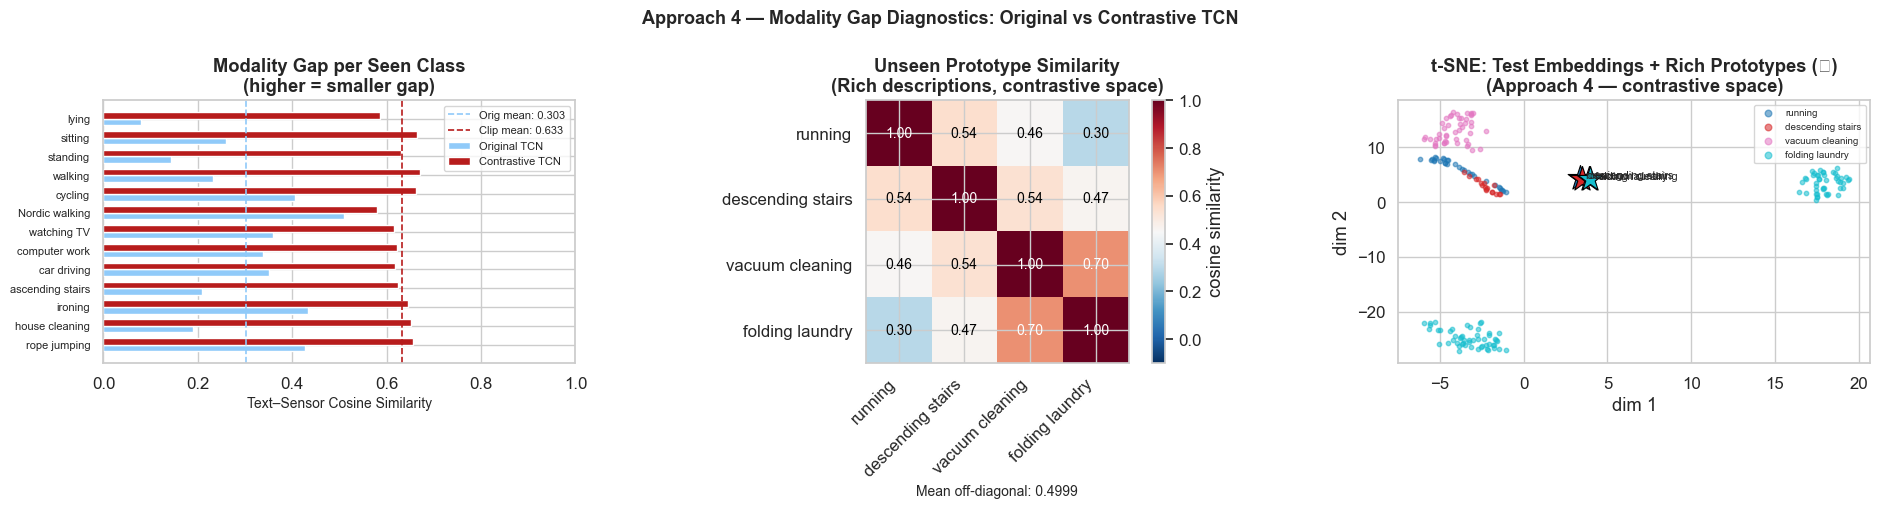

In [70]:
# ─── Modality gap visualisation ───────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(19, 5))

# ── Panel A: text–sensor cosine per seen class ────────────────────────────────
ax   = axes[0]
x_ax = np.arange(len(valid_seen))
w_   = 0.35
seen_names_v = [ACTIVITY_MAP[c] for c in valid_seen]
ax.barh(x_ax + w_/2, orig_cosines, w_, label="Original TCN",
        color="#90CAF9", edgecolor="white")
ax.barh(x_ax - w_/2, clip_cosines, w_, label="Contrastive TCN",
        color="#B71C1C", edgecolor="white")
ax.set_yticks(x_ax); ax.set_yticklabels(seen_names_v, fontsize=8)
ax.set_xlabel("Text–Sensor Cosine Similarity", fontsize=10)
ax.set_title("Modality Gap per Seen Class\n(higher = smaller gap)",
             fontweight="bold")
ax.axvline(np.mean(orig_cosines), color="#90CAF9", linestyle="--",
           linewidth=1.2, label=f"Orig mean: {np.mean(orig_cosines):.3f}")
ax.axvline(np.mean(clip_cosines), color="#B71C1C", linestyle="--",
           linewidth=1.2, label=f"Clip mean: {np.mean(clip_cosines):.3f}")
ax.legend(fontsize=8); ax.invert_yaxis()
ax.set_xlim(0, 1.0)

# ── Panel B: unseen–unseen prototype similarity (new space, using rich protos) ─
ax      = axes[1]
sim_uu_clip = proto_unseen_clip @ proto_unseen_clip.T
names_un    = [ACTIVITY_MAP[c] for c in UNSEEN]
im = ax.imshow(sim_uu_clip, vmin=-0.1, vmax=1.0, cmap="RdBu_r")
ax.set_xticks(range(len(names_un)))
ax.set_xticklabels(names_un, rotation=45, ha="right")
ax.set_yticks(range(len(names_un)))
ax.set_yticklabels(names_un)
for i in range(len(names_un)):
    for j in range(len(names_un)):
        ax.text(j, i, f"{sim_uu_clip[i,j]:.2f}", ha="center", va="center",
                fontsize=10,
                color="white" if abs(sim_uu_clip[i,j]) > 0.6 else "black")
plt.colorbar(im, ax=ax, label="cosine similarity")
mean_off_clip = float(
    sim_uu_clip[~np.eye(len(UNSEEN), dtype=bool)].mean()
)
ax.set_title("Unseen Prototype Similarity\n(Rich descriptions, contrastive space)",
             fontweight="bold")
ax.set_xlabel(f"Mean off-diagonal: {mean_off_clip:.4f}", fontsize=10)

# ── Panel C: t-SNE new space — test embeddings + prototypes ───────────────────
ax      = axes[2]
n_tsne4 = min(2000, len(E_unseen_clip))
idx_ts4 = np.random.choice(len(E_unseen_clip), n_tsne4, replace=False)
X_tsne4 = np.vstack([E_unseen_clip[idx_ts4], proto_unseen_clip])
Z4      = TSNE(n_components=2, perplexity=30, learning_rate="auto",
               init="pca", random_state=SEED).fit_transform(X_tsne4)
Z4_pts  = Z4[:n_tsne4]
Z4_star = Z4[n_tsne4:]

palette = plt.cm.get_cmap("tab10", len(UNSEEN))
for k, cid in enumerate(UNSEEN):
    m = (y_true[idx_ts4] == cid)
    if m.sum() == 0:
        continue
    ax.scatter(Z4_pts[m, 0], Z4_pts[m, 1], s=10, alpha=0.55,
               color=palette(k), label=ACTIVITY_MAP[cid])
for k, cid in enumerate(UNSEEN):
    ax.scatter(Z4_star[k, 0], Z4_star[k, 1], marker="*", s=350,
               color=palette(k), edgecolors="black", linewidths=0.8)
    ax.text(Z4_star[k, 0] + 0.3, Z4_star[k, 1],
            ACTIVITY_MAP[cid], fontsize=8)
ax.set_title("t-SNE: Test Embeddings + Rich Prototypes (★)\n"
             "(Approach 4 — contrastive space)",
             fontweight="bold")
ax.set_xlabel("dim 1"); ax.set_ylabel("dim 2")
ax.legend(fontsize=7, markerscale=1.5, loc="best")

fig.suptitle("Approach 4 — Modality Gap Diagnostics: Original vs Contrastive TCN",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, "approach4_modality_gap.png"),
            dpi=150, bbox_inches="tight")
plt.show()
plt.close()

### 14.8 Full Results Comparison — All Four Approaches

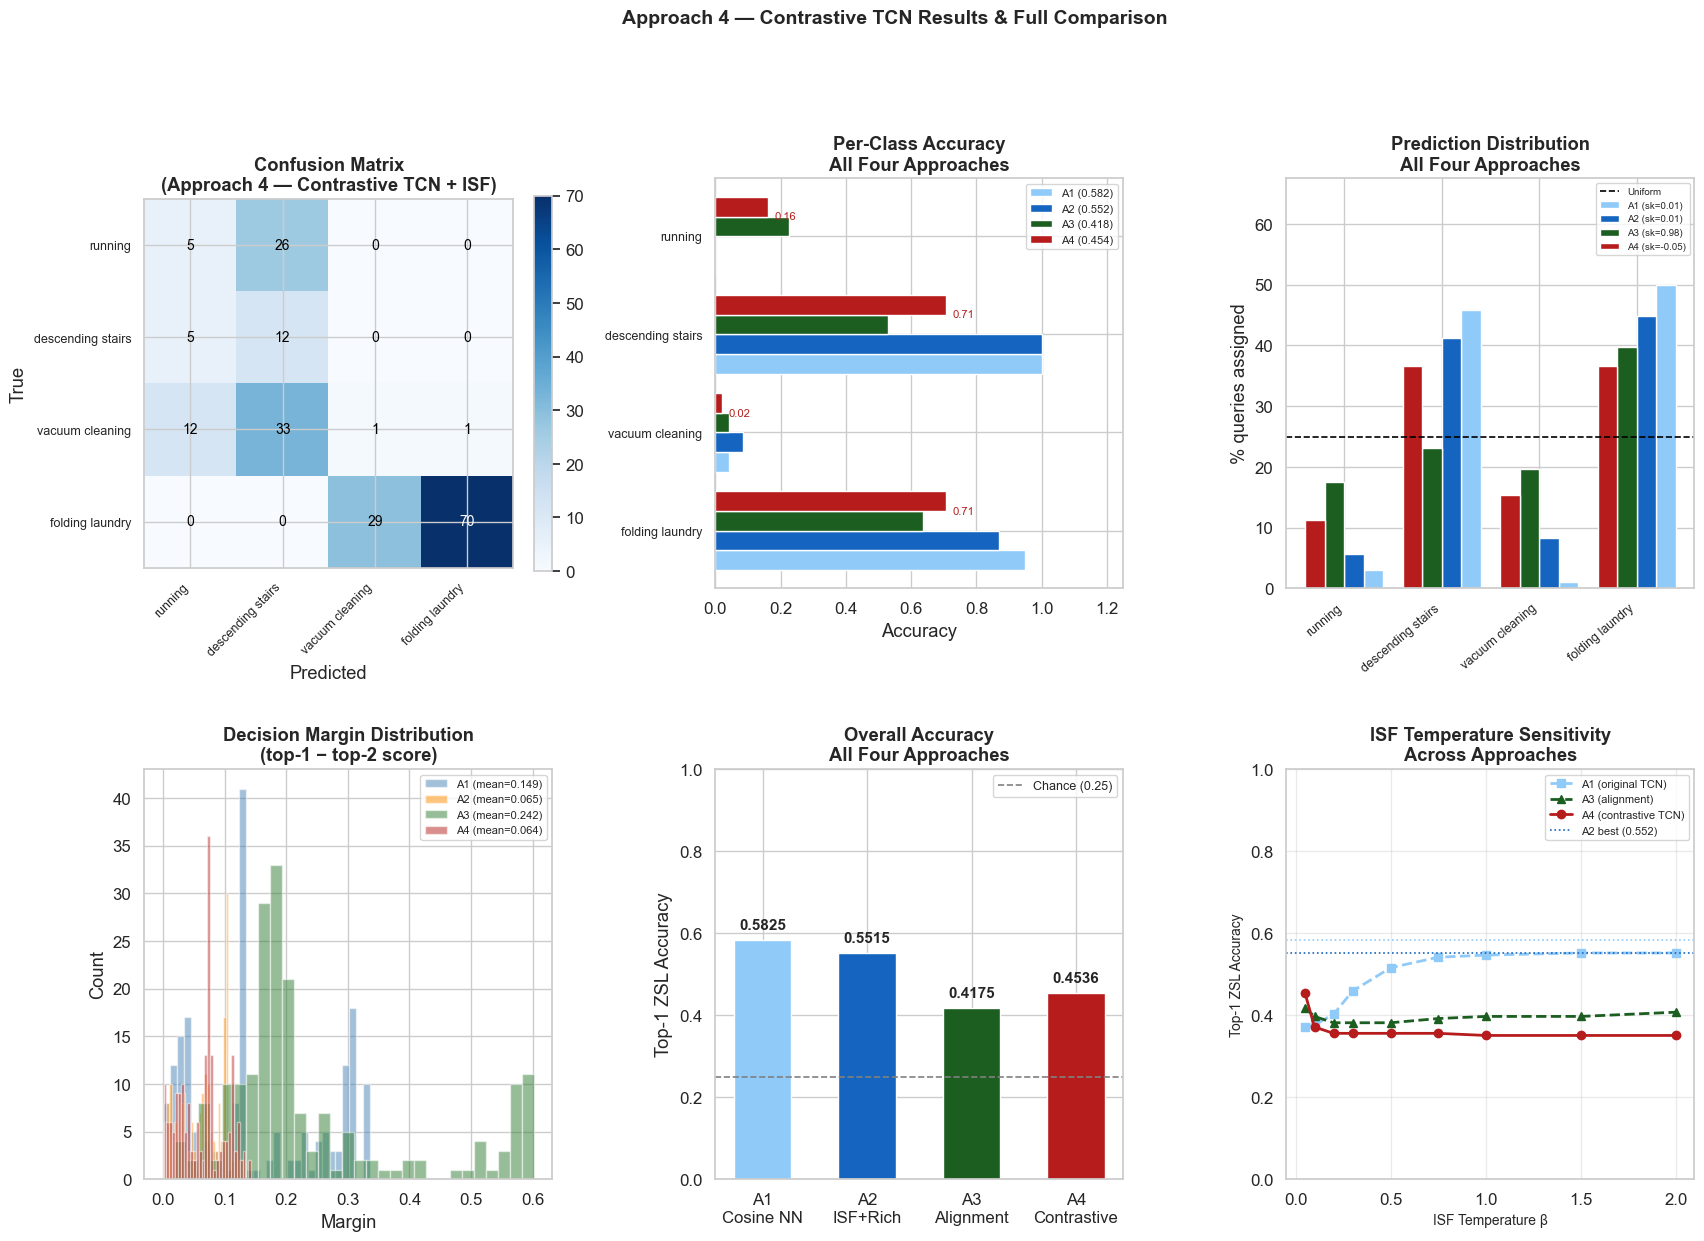


Approach 4 Overall ZSL Accuracy: 0.4536


In [71]:
# ─── Full four-approach results panel ─────────────────────────────────────────

fig = plt.figure(figsize=(20, 13))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.44, wspace=0.40)

# ── Panel A: Confusion matrix Approach 4b ─────────────────────────────────────
ax0 = fig.add_subplot(gs[0, 0])
cm4 = confusion_matrix(y_true, pred_a4b, labels=UNSEEN)
im  = ax0.imshow(cm4, cmap=CMAP)
ax0.set_title("Confusion Matrix\n(Approach 4 — Contrastive TCN + ISF)",
              fontweight="bold")
ax0.set_xticks(range(len(target_names)))
ax0.set_xticklabels(target_names, rotation=45, ha="right", fontsize=9)
ax0.set_yticks(range(len(target_names)))
ax0.set_yticklabels(target_names, fontsize=9)
ax0.set_xlabel("Predicted"); ax0.set_ylabel("True")
for i in range(len(target_names)):
    for j in range(len(target_names)):
        ax0.text(j, i, str(cm4[i, j]), ha="center", va="center", fontsize=10,
                 color="white" if cm4[i, j] > cm4.max() * 0.6 else "black")
plt.colorbar(im, ax=ax0, fraction=0.046)

# ── Panel B: Per-class accuracy four-way ──────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 1])
x   = np.arange(len(target_names))
w   = 0.20
ax1.barh(x + 1.5*w, per_cls_acc_a1,  w, label=f"A1 ({acc_a1:.3f})",
         color="#90CAF9", edgecolor="white")
ax1.barh(x + 0.5*w, per_cls_acc_a2,  w, label=f"A2 ({acc_a2:.3f})",
         color="#1565C0", edgecolor="white")
ax1.barh(x - 0.5*w, per_cls_acc_a3,  w, label=f"A3 ({acc_a3:.3f})",
         color="#1B5E20", edgecolor="white")
ax1.barh(x - 1.5*w, per_cls_acc_a4b, w, label=f"A4 ({acc_a4b:.3f})",
         color="#B71C1C", edgecolor="white")
ax1.set_xlim(0, 1.25)
ax1.set_yticks(x); ax1.set_yticklabels(target_names, fontsize=9)
ax1.set_xlabel("Accuracy")
ax1.set_title("Per-Class Accuracy\nAll Four Approaches", fontweight="bold")
ax1.legend(fontsize=8); ax1.invert_yaxis()
for i, val in enumerate(per_cls_acc_a4b):
    ax1.text(min(val + 0.02, 1.20), x[i] - 1.5*w + w/2,
             f"{val:.2f}", va="center", fontsize=8, color="#B71C1C")

# ── Panel C: Prediction distribution four-way ─────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
x2  = np.arange(len(target_names))
w2  = 0.20
ax2.bar(x2 + 1.5*w2, nn_counts_pct,    w2,
        label=f"A1 (sk={skewness:.2f})",    color="#90CAF9", edgecolor="white")
ax2.bar(x2 + 0.5*w2, nn_counts_pct_a2, w2,
        label=f"A2 (sk={skewness_a2:.2f})", color="#1565C0", edgecolor="white")
ax2.bar(x2 - 0.5*w2, nn_counts_pct_a3, w2,
        label=f"A3 (sk={skewness_a3:.2f})", color="#1B5E20", edgecolor="white")
ax2.bar(x2 - 1.5*w2, nn_counts_pct_a4, w2,
        label=f"A4 (sk={skewness_a4:.2f})", color="#B71C1C", edgecolor="white")
ax2.axhline(100 / len(UNSEEN), linestyle="--", color="black",
            linewidth=1.2, label="Uniform")
ax2.set_title("Prediction Distribution\nAll Four Approaches", fontweight="bold")
ax2.set_ylabel("% queries assigned")
ax2.set_xticks(x2)
ax2.set_xticklabels(target_names, rotation=40, ha="right", fontsize=9)
ax2.set_ylim(0, max(nn_counts_pct.max(), nn_counts_pct_a2.max(),
                    nn_counts_pct_a3.max(), nn_counts_pct_a4.max()) * 1.35)
ax2.legend(fontsize=7)

# ── Panel D: Margin distributions ────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
ax3.hist(margins,    bins=30, alpha=0.5, color="steelblue",
         edgecolor="white", label=f"A1 (mean={margins.mean():.3f})")
ax3.hist(margins_a2, bins=30, alpha=0.5, color="darkorange",
         edgecolor="white", label=f"A2 (mean={margins_a2.mean():.3f})")
ax3.hist(margins_a3, bins=30, alpha=0.5, color="#2E7D32",
         edgecolor="white", label=f"A3 (mean={margins_a3.mean():.3f})")
ax3.hist(margins_a4, bins=30, alpha=0.5, color="#B71C1C",
         edgecolor="white", label=f"A4 (mean={margins_a4.mean():.3f})")
ax3.set_title("Decision Margin Distribution\n(top-1 − top-2 score)",
              fontweight="bold")
ax3.set_xlabel("Margin"); ax3.set_ylabel("Count")
ax3.legend(fontsize=8)

# ── Panel E: Overall accuracy summary ─────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
approaches = ["A1\nCosine NN", "A2\nISF+Rich",
              "A3\nAlignment", "A4\nContrastive"]
accs       = [acc_a1, acc_a2, acc_a3, acc_a4b]
colors_e   = ["#90CAF9", "#1565C0", "#1B5E20", "#B71C1C"]
bars_e     = ax4.bar(approaches, accs, color=colors_e,
                     edgecolor="white", width=0.55)
ax4.set_ylim(0, 1.0)
ax4.axhline(1 / len(UNSEEN), linestyle="--", color="gray",
            linewidth=1.2, label=f"Chance ({1/len(UNSEEN):.2f})")
ax4.set_ylabel("Top-1 ZSL Accuracy")
ax4.set_title("Overall Accuracy\nAll Four Approaches", fontweight="bold")
ax4.legend(fontsize=9)
for bar, val in zip(bars_e, accs):
    ax4.text(bar.get_x() + bar.get_width() / 2, val + 0.02,
             f"{val:.4f}", ha="center", va="bottom",
             fontsize=11, fontweight="bold")

# ── Panel F: ISF beta sweep comparison ───────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
ax5.plot(beta_grid, beta_accs,     marker="s", linewidth=2, linestyle="--",
         color="#90CAF9", markersize=6, label="A1 (original TCN)")
ax5.plot(beta_grid, beta_accs_a3,  marker="^", linewidth=2, linestyle="--",
         color="#1B5E20", markersize=6, label="A3 (alignment)")
ax5.plot(beta_grid, beta_accs_a4b, marker="o", linewidth=2,
         color="#B71C1C", markersize=6, label="A4 (contrastive TCN)")
ax5.axhline(acc_a1,  color="#90CAF9", linestyle=":", linewidth=1.2)
ax5.axhline(acc_a2,  color="#1565C0", linestyle=":", linewidth=1.2,
            label=f"A2 best ({acc_a2:.3f})")
ax5.set_xlabel("ISF Temperature β", fontsize=10)
ax5.set_ylabel("Top-1 ZSL Accuracy", fontsize=10)
ax5.set_title("ISF Temperature Sensitivity\nAcross Approaches",
              fontweight="bold")
ax5.legend(fontsize=8); ax5.grid(True, alpha=0.4); ax5.set_ylim(0, 1)

fig.suptitle("Approach 4 — Contrastive TCN Results & Full Comparison",
             fontsize=14, fontweight="bold", y=1.01)
plt.savefig(os.path.join(VIS_DIR, "approach4_results.png"),
            dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print(f"\nApproach 4 Overall ZSL Accuracy: {acc_a4b:.4f}")